# Extended BTFR MaNGA paper plots
* ~~CMD diagram~~
* ~~stellar mass density + profile '8319-1902'~~
* ~~stellar velocity disp and corrected stellar velocity disp~~
* ~~stellar mass and total mass vs Mr~~
* ~~ellipticals pipe3d modeled Mstar vs NSA Mstar~~
* ~~MaNGA Illustris matching plots~~
* ~~Mstar vs Mtot for MaNGA Illustris matched samples~~
* ~~BTFR for matched samples (MCMC and fixed slope 4)~~
  * ~~without points only means~~
  * ~~MCMC contours~~
* ~~BTFR for full Illustris sample (contours)~~
* ~~BPT~~
* ~~metallicity~~
* ~~sf, stellar z, age~~

#### imports and data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from astropy.table import Table, vstack,hstack
import numpy.ma as ma
import matplotlib.cm as cm

import emcee
import corner

# import marvin
import pyneb as pn
import sys
sys.path.insert(1, '/Users/nityaravi/Documents/Github/RotationCurves/ellipticals')
from elliptical_plottingFunctions import *
from IO_data import *
from elliptical_stellar_mass import calc_mass_curve
from elliptical_stellar_mass_functions import exponential_disk, exponential_sphere, exponential_sphere_disk
from matplotlib.lines import Line2D

from scipy.optimize import curve_fit
from scipy.optimize import minimize

sys.path.insert(1, '/Users/nityaravi/Documents/Github/RotationCurves/spirals')
from SHMR_functions import shmr_RP11

In [2]:
master_table_fn = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_BPT_illustris_v11.fits'

master_table = Table.read(master_table_fn)
master_table[:5]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,nsa_elpetro_log_mass,rabsmag,param_H2_R90,logHe,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err,BPT_class,spiral_mask,elliptical_mask,Age_LW_Re_fit,Age_MW_Re_fit,ZH_LW_Re_fit,ZH_MW_Re_fit,M90_disk_h,M90_disk_err_h,sphd_M_star_err_h,sphd_M_star_h,V_R90,V_R90_err,e_M_star_R90,e_M_star_R90_err,e_M_star_R90_h,e_M_star_R90_err_h,v_eff,v_eff_err,logHI,logHI_err,HI_catalog,logHI_h,logHI_err_h,N2Ha,O3Hb,nsa_u_r,illustris_match,illustris_dist,illustris_u_r,illustris_Mstar,illustris_Mstar_Sal,illustris_Vmax,illustris_flag,illustris_MR90,MH2_S14_vol,MHI_S14_vol,MHtot
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,

In [3]:
master_table_dict = {}
for i in range(len(master_table)):
    master_table_dict[master_table['plateifu'][i]] = i

In [4]:
PIPE3D_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Pipe3D/'
DATA_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/'
VEL_FOLDER = DATA_FOLDER + 'DR17/'


matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['savefig.dpi'] = 300

In [5]:
plot_dir = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Ellipticals_Images/BTFR_paper/'

In [6]:
ellipticals = master_table[master_table['elliptical_mask']==1]
spirals = master_table[master_table['spiral_mask']==1]

In [7]:
nsa_portsmouth = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/NSA_v1_0_1_vflag_Portsmouth.fits')
nsa_portsmouth[:5]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS,u_r,g_r,NUV_r,index,imc,aimc,cd,conx1,u_r_KIAS,prmag,BPTclass,SFR,sSFR,HImass,vflag,u_r_err,g_r_err,NUV_r_err,ID,Flux_OII_3726,Flux_OII_3726_Err,AoN_OII_3726,Flux_OII_3728,Flux_OII_3728_Err,AoN_OII_3728,Flux_OIII_4363,Flux_OIII_4363_Err,AoN_OIII_4363,Flux_Hb_4861,Flux_Hb_4861_Err,AoN_Hb_4861,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,AoN_OIII_5006,Flux_NI_5197,Flux_NI_5197_Err,AoN_NI_5197,Flux_NI_5200,Flux_NI_5200_Err,AoN_NI_5200,Flux_OI_6300,Flux_OI_6300_Err,AoN_OI_6300,Flux_OI_6363,Flux_OI_6363_Err,AoN_OI_6363,Flux_NII_6547,Flux_NII_6547_Err,Flux_Ha_6562,Flux_Ha_6562_Err,AoN_Ha_6562,Flux_NII_6583,Flux_NII_6583_Err,AoN_NII_6583,Flux_SII_6716,Flux_SII_6716_Err,AoN_SII_6716,Flux_SII_6730,Flux_SII_6730_Err,AoN_SII_6730
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64,float32,float32,float32,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
J023211.77+001326.5,02h/p00/J023211.77+001326.5,38.04906209256324,0.22402153989646575,39438,22721,-1,-1,71327,-1,16.771198,0.054021582,sdss,0.07,109,4,23,301,1960.5631,83.361275,38979,0.054392263,1.3420134 .. 884.58374,16.215242 .. 0.0016165179,1,1.4780203 .. 964.8986,-13.908231 .. -21.045618,24.77356 .. 1073.0248,0.2271526 .. 0.04052578,-0.060923357 .. 0.029009609,1.4557369e-05 .. 1.222673e-15,0.0016189957 .. 1.23927,2.5023096e-06,0.06656253,0.024689334,22540354000.0,156.48558044433594,201.36697387695312,10 .. 11,0.016490662 .. 0.0,5489.7393 .. 0.0,0.21582535 .. -0.09177922,0.0076095443 .. 0.15974313,0.64479166 ..

In [8]:
nsa_dict = {}
for i in range(len(nsa_portsmouth)):
    nsa_dict[nsa_portsmouth['NSAID'][i]] = i

In [9]:
G = 4.3009 * 10**-6 # [kpc (km/s)^2 / M_sun]
H_0 = 100 # [km / s / Mpc]
c = 299792.458 # Speed of light in units of km/s

In [10]:
blue_spirals = spirals[spirals['CMD_class'] == 1]
green_spirals = spirals[spirals['CMD_class']==2]
red_spirals = spirals[spirals['CMD_class']==3]

In [11]:
mcg = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/McGaugh_2012.csv', format='csv')
mcg[:5]

Galaxy,D,V_f,V_f_err,Mstar,Mstar_err,Mg,Mg_err
str8,float64,int64,int64,float64,float64,float64,float64
DDO 210,0.94,17,4,5.88,0.15,6.64,0.2
Cam B,3.34,20,12,6.99,0.15,7.33,0.2
UGC 8215,4.5,20,6,6.81,0.15,7.45,0.2
DDO 183,3.24,25,3,7.24,0.15,7.54,0.2
UGC 8833,3.2,27,4,6.94,0.15,7.3,0.2


In [12]:
torflor = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/torres_flores_2011.csv', format='csv')
torflor[:5]

Galaxy UGC,Mbar,Mbar_err,V_TF,V_TF_err
int64,float64,float64,int64,int64
89,11.37,0.1,343,117
94,10.72,0.08,209,21
763,9.81,0.06,104,11
1317,11.23,0.09,205,9
2141,9.82,0.08,157,20


In [13]:
i_sample = master_table[master_table['illustris_match'] >= 0]

In [14]:
HI_spirals = spirals[spirals['logHI_h']>0]
HI_spirals['Mstar_MHI_h'] = np.log10(10**HI_spirals['sphd_M_star_h'] + 10**HI_spirals['logHI_h'])
HI_spirals['Mstar_MHI_err_h'] = 0.5*np.log10((10**HI_spirals['sphd_M_star_err_h'])**2 + (10**HI_spirals['logHI_err_h'])**2)

In [15]:
HI_s_match = master_table[np.logical_and(np.logical_and(master_table['logHI_h'] > 0, master_table['spiral_mask']==1),
                                         master_table['illustris_match'] >= 0)]

HI_s_match['Mstar_MHI_h'] = np.log10(10**HI_s_match['sphd_M_star_h'] + 10**HI_s_match['logHI_h'])
HI_s_match['Mstar_MHI_err_h'] = 0.5*np.log10((10**HI_s_match['sphd_M_star_err_h'])**2 + (10**HI_s_match['logHI_err_h'])**2)

HI_s_match['illustris_Mstar_MHI_h'] = np.log10(10**HI_s_match['illustris_Mstar_Sal'] + 10**HI_s_match['MHI_S14_vol'])

In [16]:
p3d = Table.read(DATA_FOLDER + 'SDSS17Pipe3D_v3_1_1.fits', format='fits')
p3d[:5]

name,plate,ifudsgn,plateifu,mangaid,objra,objdec,log_SFR_Ha,FoV,Re_kpc,e_log_Mass,e_log_SFR_Ha,log_Mass,log_SFR_ssp,log_NII_Ha_cen,e_log_NII_Ha_cen,log_OIII_Hb_cen,e_log_OIII_Hb_cen,log_SII_Ha_cen,e_log_SII_Ha_cen,log_OII_Hb_cen,e_log_OII_Hb_cen,EW_Ha_cen,e_EW_Ha_cen,ZH_LW_Re_fit,e_ZH_LW_Re_fit,alpha_ZH_LW_Re_fit,e_alpha_ZH_LW_Re_fit,ZH_MW_Re_fit,e_ZH_MW_Re_fit,alpha_ZH_MW_Re_fit,e_alpha_ZH_MW_Re_fit,Age_LW_Re_fit,e_Age_LW_Re_fit,alpha_Age_LW_Re_fit,e_alpha_Age_LW_Re_fit,Age_MW_Re_fit,e_Age_MW_Re_fit,alpha_Age_MW_Re_fit,e_alpha_Age_MW_Re_fit,Re_arc,DL,DA,PA,ellip,log_Mass_gas,vel_sigma_Re,e_vel_sigma_Re,log_SFR_SF,log_SFR_D_C,OH_O3N2_cen,e_OH_O3N2_cen,OH_N2_cen,e_OH_N2_cen,OH_ONS_cen,e_OH_ONS_cen,OH_R23_cen,e_OH_R23_cen,OH_pyqz_cen,e_OH_pyqz_cen,OH_t2_cen,e_OH_t2_cen,OH_M08_cen,e_OH_M08_cen,OH_T04_cen,e_OH_T04_cen,OH_dop_cen,e_OH_dop_cen,OH_O3N2_EPM09_cen,e_OH_O3N2_EPM09_cen,log_OI_Ha_cen,e_log_OI_Ha_cen,Ha_Hb_cen,e_Ha_Hb_cen,log_NII_Ha_Re,e_log_NII_Ha_Re,log_OIII_Hb_Re,e_log_OIII_Hb_Re,log_SII_Ha_Re,e_log_SII_Ha_Re,log_OII_Hb_Re,e_log_OII_Hb_Re,log_OI_Ha_Re,e_log_OI_Ha_Re,EW_Ha_Re,e_EW_Ha_Re,Ha_Hb_Re,e_Ha_Hb_Re,log_NII_Ha_ALL,e_log_NII_Ha_ALL,log_OIII_Hb_ALL,e_log_OIII_Hb_ALL,log_SII_Ha_ALL,e_log_SII_Ha_ALL,log_OII_Hb_ALL,e_log_OII_Hb_ALL,log_OI_Ha_ALL,e_log_OI_Ha_ALL,EW_Ha_ALL,e_EW_Ha_ALL,Ha_Hb_ALL,Sigma_Mass_cen,e_Sigma_Mass_cen,Sigma_Mass_Re,e_Sigma_Mass_Re,Sigma_Mass_ALL,e_Sigma_Mass_ALL,T30,ZH_T30,ZH_Re_T30,a_ZH_T30,T40,ZH_T40,ZH_Re_T40,a_ZH_T40,T50,ZH_T50,ZH_Re_T50,a_ZH_T50,T60,ZH_T60,ZH_Re_T60,a_ZH_T60,T70,ZH_T70,ZH_Re_T70,a_ZH_T70,T80,ZH_T80,ZH_Re_T80,a_ZH_T80,T90,ZH_T90,ZH_Re_T90,a_ZH_T90,T95,ZH_T95,ZH_Re_T95,a_ZH_T95,T99,ZH_T99,ZH_Re_T99,a_ZH_T99,log_Mass_gas_Av_gas_OH,log_Mass_gas_Av_ssp_OH,vel_ssp_2,e_vel_ssp_2,vel_Ha_2,e_vel_Ha_2,vel_ssp_1,e_vel_ssp_1,vel_Ha_1,e_vel_Ha_1,log_SFR_ssp_100Myr,log_SFR_ssp_10Myr,vel_disp_Ha_cen,vel_disp_ssp_cen,vel_disp_Ha_1Re,vel_disp_ssp_1Re,log_Mass_in_Re,ML_int,ML_avg,F_Ha_cen,e_F_Ha_cen,R50_kpc_V,e_R50_kpc_V,R50_kpc_Mass,e_R50_kpc_Mass,log_Mass_corr_in_R50_V,e_log_Mass_corr_in_R50_V,log_Mass_gas_Av_gas_log_log,Av_gas_Re,e_Av_gas_Re,Av_ssp_Re,e_Av_ssp_Re,Lambda_Re,e_Lambda_Re,nsa_redshift,nsa_mstar,nsa_inclination,flux_[OII]3726.03_Re_fit,e_flux_[OII]3726.03_Re_fit,flux_[OII]3726.03_alpha_fit,e_flux_[OII]3726.03_alpha_fit,flux_[OII]3728.82_Re_fit,e_flux_[OII]3728.82_Re_fit,flux_[OII]3728.82_alpha_fit,e_flux_[OII]3728.82_alpha_fit,flux_HI3734.37_Re_fit,e_flux_HI3734.37_Re_fit,flux_HI3734.37_alpha_fit,e_flux_HI3734.37_alpha_fit,flux_HI3797.9_Re_fit,e_flux_HI3797.9_Re_fit,flux_HI3797.9_alpha_fit,e_flux_HI3797.9_alpha_fit,flux_HeI3888.65_Re_fit,e_flux_HeI3888.65_Re_fit,flux_HeI3888.65_alpha_fit,e_flux_HeI3888.65_alpha_fit,flux_HI3889.05_Re_fit,e_flux_HI3889.05_Re_fit,flux_HI3889.05_alpha_fit,e_flux_HI3889.05_alpha_fit,flux_HeI3964.73_Re_fit,e_flux_HeI3964.73_Re_fit,flux_HeI3964.73_alpha_fit,e_flux_HeI3964.73_alpha_fit,flux_[NeIII]3967.46_Re_fit,e_flux_[NeIII]3967.46_Re_fit,flux_[NeIII]3967.46_alpha_fit,e_flux_[NeIII]3967.46_alpha_fit,flux_CaII3968.47_Re_fit,e_flux_CaII3968.47_Re_fit,flux_CaII3968.47_alpha_fit,e_flux_CaII3968.47_alpha_fit,flux_Hepsilon3970.07_Re_fit,e_flux_Hepsilon3970.07_Re_fit,flux_Hepsilon3970.07_alpha_fit,e_flux_Hepsilon3970.07_alpha_fit,flux_Hdelta4101.77_Re_fit,e_flux_Hdelta4101.77_Re_fit,flux_Hdelta4101.77_alpha_fit,e_flux_Hdelta4101.77_alpha_fit,flux_Hgamma4340.49_Re_fit,e_flux_Hgamma4340.49_Re_fit,flux_Hgamma4340.49_alpha_fit,e_flux_Hgamma4340.49_alpha_fit,flux_Hbeta4861.36_Re_fit,e_flux_Hbeta4861.36_Re_fit,flux_Hbeta4861.36_alpha_fit,e_flux_Hbeta4861.36_alpha_fit,flux_[OIII]4958.91_Re_fit,e_flux_[OIII]4958.91_Re_fit,flux_[OIII]4958.91_alpha_fit,e_flux_[OIII]4958.91_alpha_fit,flux_[OIII]5006.84_Re_fit,e_flux_[OIII]5006.84_Re_fit,flux_[OIII]5006.84_alpha_fit,e_flux_[OIII]5006.84_alpha_fit,flux_HeI5015.68_Re_fit,e_flux_HeI5015.68_Re_fit,flux_HeI5015.68_alpha_fit,e_flux_HeI5015.68_alpha_fit,flux_[NI]5197.9_Re_fit,e_flux_[NI]5197.9_Re_fit,flux_[NI]5197.9_alpha_fit

In [17]:
p3d_dict = {}
for i in range(len(p3d)):
    p3d_dict[p3d[i]['plateifu']] = i

In [18]:
ellipticals['Age_LW_Re_fit'] = -99.
ellipticals['Age_MW_Re_fit'] = -99.
ellipticals['ZH_LW_Re_fit'] = -99.
ellipticals['ZH_MW_Re_fit'] = -99.

for i in range(len(ellipticals)):

    try:

        i_p = p3d_dict[ellipticals[i]['plateifu']]

        ellipticals['Age_LW_Re_fit'][i] = p3d[i_p]['Age_LW_Re_fit']
        ellipticals['Age_MW_Re_fit'][i] = p3d[i_p]['Age_MW_Re_fit']
        ellipticals['ZH_LW_Re_fit'][i] = p3d[i_p]['ZH_LW_Re_fit']
        ellipticals['ZH_MW_Re_fit'][i] = p3d[i_p]['ZH_MW_Re_fit']
    
    except:
        print(ellipticals[i]['plateifu'])

10496-3704
10837-12702
11980-3703
12678-3702
12683-1902
9514-6102


/Users/nityaravi/miniforge3/envs/RotationCurves/lib/python3.12/site-packages/astropy/table/column.py:1376: UserWarning: Warning: converting a masked element to nan.
  self.data[index] = value


#### functions

In [19]:
def lin_fit(x, a, b):

    return a*x + b

def lin_fit_fixed_slope(x, b):

    return x + b

def chi2_norm(model, data, err, dof):

    return np.sum(((model-data)/err)**2)/(len(data)-dof)

In [20]:
def logl(params, x, y, dy):

    '''
    PARAMETERS
    ==========

    a : slope
    b : y int
    
    '''

    a, b = params

    model = a * x + b

    return -0.5 * np.sum((y-model)**2/dy**2 + np.log(2*np.pi*dy**2))

def log_prior(params):

    a, b = params
    if -10 < a < 10 and -10 < b < 10:
        return 0.

    return -np.inf

def log_prob(params, x, y, dy):

    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf

    return lp + logl(params, x, y, dy)
    

## CMD diagram

In [21]:
cmd_color_dict = {1.0: 'b',
            2.0: 'g',
            3.0:'r',
            -99: 'k',
           -1: 'k'}
cmd_marker_dict = {1.0: '+',
            2.0: '*',
            3.0:'.',
            -99: '.',
           -1: '.'}
cmd_fc_dict = {1.0: None,
            2.0: None,
            3.0:'none',
            -99: None,
           -1: None}

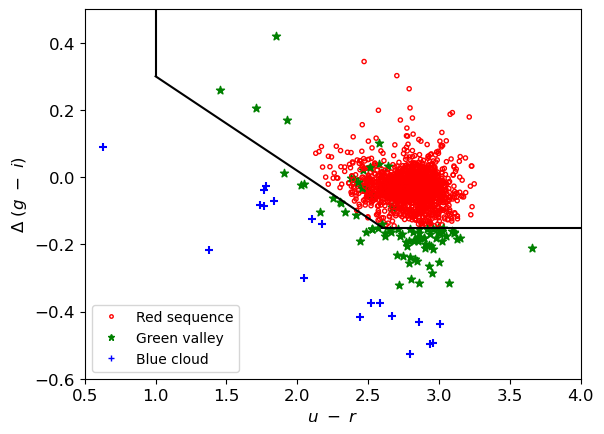

In [22]:
for i in range(len(ellipticals)):
    nsaid = ellipticals[i]['nsa_nsaid']
    nsa_idx = nsa_dict[nsaid]

    plt.scatter(nsa_portsmouth['u_r_KIAS'][nsa_idx], nsa_portsmouth['cd'][nsa_idx], marker=cmd_marker_dict[ellipticals[i]['CMD_class']], 
                color=cmd_color_dict[ellipticals[i]['CMD_class']], 
               facecolor=cmd_fc_dict[ellipticals[i]['CMD_class']],
               )


plt.xlim(0.5,4)
plt.ylim(-0.6,0.5)
plt.xlabel(r'$u\ -\ r$', fontsize=12)
plt.ylabel(r'$\Delta\ (g\ -\ i)$', fontsize=12)
plt.plot([4,2.6],[-0.15,-0.15], color='k')
plt.plot([2.6,1.0],[-0.15,0.3], color='k')
plt.plot([1.0,1.0],[0.3,10], color='k')




legend_elements = [Line2D([0], [0], marker='.', color='w', label='Red sequence',
                          markeredgecolor='r', markersize=5),
                   Line2D([0], [0], marker='*', color='w', label='Green valley',
                          markeredgecolor='g', markerfacecolor='g', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='Blue cloud',
                          markeredgecolor='b', markerfacecolor='b', markersize=5)]
plt.tick_params( axis='both', labelsize=12)


plt.legend(handles=legend_elements, loc='lower left')
plt.savefig(plot_dir + 'CMD.png', bbox_inches='tight')

## test gal set up

In [23]:
gal_ID = '8319-1902'
pipe3d_maps = extract_Pipe3d_data(PIPE3D_FOLDER, '8319-1902', ['sMass'])
dap_maps = extract_data(VEL_FOLDER, '8319-1902', ['star_sigma', 'flux'])

idx = master_table_dict[gal_ID]
sMass = pipe3d_maps['sMass_density']
sMass_err = pipe3d_maps['sMass_density_err']
flux = dap_maps['mflux']
ba = master_table['nsa_elpetro_ba'][idx]
z = master_table['nsa_z'][idx]
phi = master_table['nsa_elpetro_phi'][idx]
R90 = master_table['R90_kpc'][idx]
Mstar = master_table['sphd_M_star'][idx]
Mstar_R90 = master_table['e_M_star_R90'][idx]

## stellar mass density and profile

In [24]:
sMass_density = pipe3d_maps['sMass_density']
msMass_density = ma.array(sMass_density, mask=np.isnan(sMass_density))

### stellar mass density map

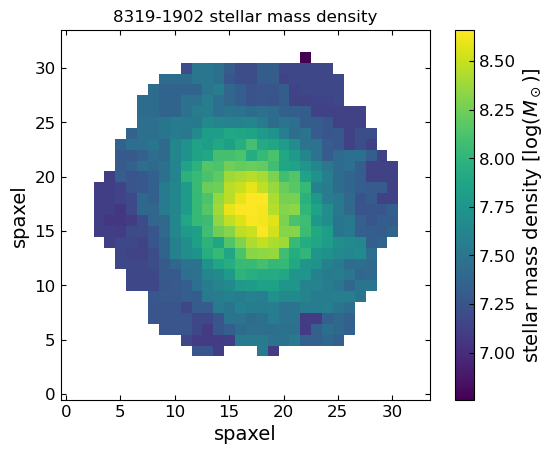

In [25]:
fig, ax = plt.subplots()

vmax = ma.max(msMass_density)
#cbar_ticks = np.linspace( 0, vmax, 11, dtype='int')

ax.set_title(gal_ID + ' stellar mass density', fontsize=12)
############################################################################


############################################################################
# Create plot
#---------------------------------------------------------------------------
vel_im = ax.imshow( msMass_density, 
                    cmap='viridis', 
                    origin='lower', 
                    #vmin=0, 
                    #vmax=vmax
                  )

cbar = plt.colorbar( vel_im, ax=ax)
cbar.ax.tick_params( direction='in', labelsize=12)
cbar.set_label(r'stellar mass density $[\log(M_\odot)]$', fontsize=14) 

ax.tick_params( axis='both', direction='in', labelsize=12)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.set_xlabel('spaxel', fontsize=14)
ax.set_ylabel('spaxel', fontsize=14)

plt.savefig( plot_dir + gal_ID + '_sMass_density.png', 
             format='png', 
             bbox_inches = 'tight', 
             pad_inches = 0
             )

### stellar mass profile

In [26]:
mass_table = calc_mass_curve(sMass, sMass_err, flux, ba, phi, z)
rs = np.linspace(np.min(mass_table['radius']), np.max(mass_table['radius']), 1000)
sph = exponential_sphere(rs, 10**master_table['sphd_rho_c'][idx], master_table['sphd_R_scale'][idx])
disk = exponential_disk(rs, 10**master_table['sphd_Sigma_d'][idx], master_table['sphd_R_d'][idx])
sphdisk = exponential_sphere_disk(rs, master_table['sphd_rho_c'][idx], master_table['sphd_R_scale'][idx],
                                  master_table['sphd_Sigma_d'][idx], master_table['sphd_R_d'][idx])
mass_table['M_star_err'] = mass_table['M_star_err'] + np.max(mass_table['M_star'])-2.5

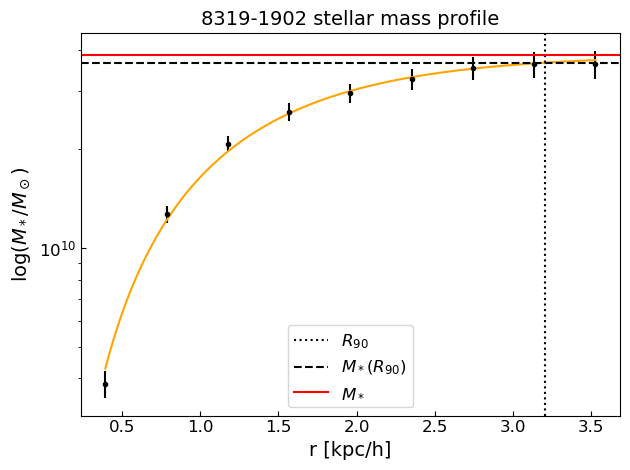

In [27]:
plt.errorbar(mass_table['radius'], 10**mass_table['M_star'], yerr=10**mass_table['M_star_err'], color='k', fmt='.')
# plt.plot(rs, sph, color='dodgerblue', linestyle='--', label='sphere')
# plt.plot(rs, disk, color='crimson', linestyle='--', label='disk')
plt.plot(rs, sphdisk, color='orange')
plt.yscale('log')
plt.xlabel('r [kpc/h]', fontsize=14)
plt.ylabel(r'$\log(M_*/M_\odot)$',fontsize=14)
# ax[1].legend(loc='lower right', )
plt.tick_params( axis='both', direction='in', labelsize=12)


#R90, M(R90), M*
plt.axvline(R90, color='k', linestyle=':', label=r'$R_{90}$')
plt.axhline(10**Mstar_R90, color='k', linestyle='--', label=r'$M_*(R_{90})$')

plt.axhline(10**Mstar, color='r', label = r'$M_*$')
plt.legend(fontsize=12)

plt.title(gal_ID + ' stellar mass profile', fontsize=14)
plt.tight_layout()
plt.savefig(plot_dir + gal_ID +  '_smass_sphd_fit.png', bbox_inches='tight', pad_inches=0)

## stellar velocity dispersion

In [28]:
star_sigma = dap_maps['star_sigma']
star_sigma_mask = dap_maps['star_sigma_mask']
star_sigma_correction = dap_maps['star_sigma_corr']

mstar_sigma = ma.array(star_sigma, mask=star_sigma_mask)
mstar_sigma_correction = ma.array(star_sigma_correction, mask=star_sigma_mask)
mstar_sigma_corr = np.sqrt(mstar_sigma**2 - mstar_sigma_correction**2)

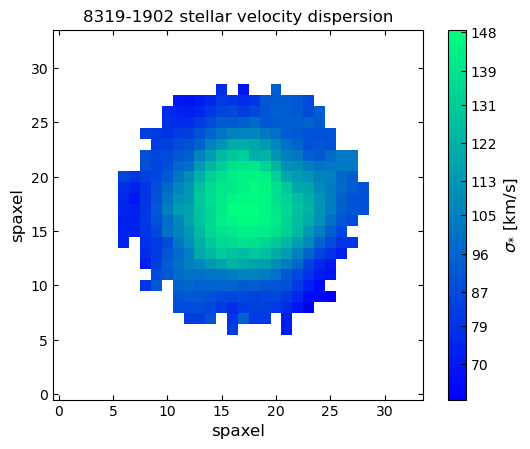

In [29]:
fig, ax = plt.subplots()

cbar_ticks = np.linspace(ma.min(mstar_sigma), ma.max(mstar_sigma), 11, dtype='int')
ax.set_title(gal_ID + ' stellar velocity dispersion', fontsize=12)

vel_im = ax.imshow( mstar_sigma, 
                    cmap='winter', # 4h 
                    origin='lower', 
                    vmin=ma.min(mstar_sigma), 
                    vmax=ma.max(mstar_sigma))

cbar = plt.colorbar( vel_im, ax=ax, ticks=cbar_ticks)
cbar.ax.tick_params( direction='in', labelsize=10)
cbar.set_label(r'$\sigma_{*}$ [km/s]', fontsize=12) 

ax.tick_params( axis='both', direction='in', labelsize=10)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.set_xlabel('spaxel', fontsize=12)
ax.set_ylabel('spaxel', fontsize=12)
ax.set_title('8319-1902 stellar velocity dispersion')


plt.savefig(plot_dir + gal_ID + '_stel_sigma.png', bbox_inches='tight', pad_inches=0)

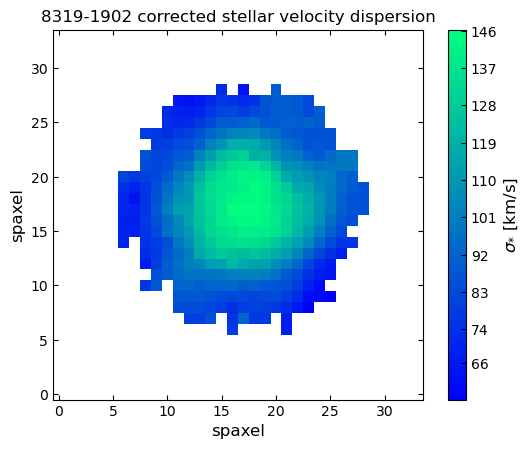

In [30]:
fig, ax = plt.subplots()

cbar_ticks = np.linspace(ma.min(mstar_sigma_corr), ma.max(mstar_sigma_corr), 11, dtype='int')
ax.set_title(gal_ID + ' stellar velocity dispersion', fontsize=12)

vel_im = ax.imshow( mstar_sigma_corr, 
                    cmap='winter', # 4h 
                    origin='lower', 
                    vmin=ma.min(mstar_sigma_corr), 
                    vmax=ma.max(mstar_sigma_corr))

cbar = plt.colorbar( vel_im, ax=ax, ticks=cbar_ticks)
cbar.ax.tick_params( direction='in', labelsize=10)
cbar.set_label(r'$\sigma_{*}$ [km/s]', fontsize=12) 

ax.tick_params( axis='both', direction='in', labelsize=10)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.set_xlabel('spaxel', fontsize=12)
ax.set_ylabel('spaxel', fontsize=12)
ax.set_title('8319-1902 corrected stellar velocity dispersion')


plt.savefig(plot_dir + gal_ID + '_stel_sigma_corr.png', bbox_inches='tight', pad_inches=0)

## Mstar and Mtot vs Mr

#### define Mr bins

In [31]:
mr_bins =  np.linspace(np.min([np.min(spirals['rabsmag']), np.min(ellipticals['rabsmag'])])-0.01,
                  np.max([np.max(spirals['rabsmag']), np.max(ellipticals['rabsmag'])]), 15)

#### ellipticals mstar

In [32]:
e_mr_mstar_ctrs = []
e_mstar = []
e_mr_mstar_bins = mr_bins
e_mr_mstar_bins = np.concatenate((mr_bins[0:7], mr_bins[-1:]))

indices = np.digitize(ellipticals['rabsmag'], e_mr_mstar_bins, right=True)

for i in range(1,len(e_mr_mstar_bins)):

    e_mstar.append(ellipticals['e_M_star_R90_h'][indices==i])
    e_mr_mstar_ctrs.append(np.mean(ellipticals['rabsmag'][indices==i]))

e_mstar_avg, e_mstar_sig = fit_to_gaussian(e_mstar, plot_dir = plot_dir + '/ellipticals_mr_mstar90/', plot_name='ellipticals_Mstar90_Mr', xlab=r'$M_*$', plot_bins=e_mr_mstar_bins, bin_lab=r'$M_r$', bin_order='flip')
e_mstar_popt, e_mstar_pcov = curve_fit(lin_fit, e_mr_mstar_ctrs, 
                                       e_mstar_avg, sigma=e_mstar_sig)
print(e_mstar_popt, np.sqrt(e_mstar_pcov[0,0]), np.sqrt(e_mstar_pcov[1,1]))


[-0.37915658  2.98926737] 0.005645582463171177 0.1216006648223951


In [33]:
# write data to a file 
f = open(plot_dir + '/ellipticals_mr_mstar90/data.txt', 'x')
f.write('e_mr_centers \n')
f.write(str(e_mr_mstar_ctrs) + '\n')
f.write('e_mr_mstar_avgs \n')
f.write(str(e_mstar_avg)+ '\n')
f.write('e_mr_mstar_sigs \n')
f.write(str(e_mstar_sig)+ '\n')

f.write('slope \n')
f.write(str(e_mstar_popt[0]) + ' +- ' + str(np.sqrt(e_mstar_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(e_mstar_popt[1]) + ' +- ' + str(np.sqrt(e_mstar_pcov[1,1]))+ '\n')
f.close()



#### ellipticals mtot

In [34]:
# ellipticals
e_mr_mtot_ctrs = []
e_mtot = []
e_mr_mtot_bins = mr_bins
e_mr_mtot_bins = np.concatenate((mr_bins[0:9], mr_bins[-1:]))

indices = np.digitize(ellipticals['rabsmag'], e_mr_mtot_bins, right=True)

for i in range(1,len(e_mr_mtot_bins)):

    e_mtot.append(ellipticals['Mvir'][indices==i])
    e_mr_mtot_ctrs.append(np.mean(ellipticals['rabsmag'][indices==i]))

e_mtot_avg, e_mtot_sig = fit_to_gaussian(e_mtot, plot_dir = plot_dir + '/ellipticals_mr_mtot/', plot_name='ellipticals_Mtot_Mr', xlab=r'$M_{\rm tot}$', plot_bins=e_mr_mtot_bins, bin_lab=r'$M_r$',  bin_order='flip')

# fit da lines

e_mtot_popt, e_mtot_pcov = curve_fit(lin_fit, e_mr_mtot_ctrs, 
                                       e_mtot_avg, sigma=e_mtot_sig)

print(e_mtot_popt, np.sqrt(e_mtot_pcov[0,0]), np.sqrt(e_mtot_pcov[1,1]))

[-0.50833911  0.58685386] 0.011118672655679309 0.23755671134314796


In [35]:
# write data to a file 
f = open(plot_dir + '/ellipticals_mr_mtot/data.txt', 'x')
f.write('e_mr_centers \n')
f.write(str(e_mr_mtot_ctrs) + '\n')
f.write('e_mr_mtot_avgs \n')
f.write(str(e_mtot_avg)+ '\n')
f.write('e_mr_mtot_sigs \n')
f.write(str(e_mtot_sig)+ '\n')

f.write('slope \n')
f.write(str(e_mtot_popt[0]) + ' +- ' + str(np.sqrt(e_mtot_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(e_mtot_popt[1]) + ' +- ' + str(np.sqrt(e_mtot_pcov[1,1]))+ '\n')
f.close()



#### blue spiral mstar

In [36]:
bs_mr_mstar_ctrs = []
bs_mstar = []
bs_mr_mstar_bins = mr_bins
bs_mr_mstar_bins = np.concatenate((mr_bins[:0], mr_bins[3:-5], mr_bins[-1:]))

indices = np.digitize(blue_spirals['rabsmag'], bs_mr_mstar_bins, right=True)

for i in range(1,len(bs_mr_mstar_bins)):

    bs_mstar.append(blue_spirals['M90_disk_h'][indices==i])
    bs_mr_mstar_ctrs.append(np.mean(blue_spirals['rabsmag'][indices==i]))

bs_mstar_avg, bs_mstar_sig = fit_to_gaussian(bs_mstar, plot_dir = plot_dir + '/bspiral_mr_mstar90/', plot_name='bspiral_Mstar90_Mr', xlab=r'$M_*$', plot_bins=bs_mr_mstar_bins, bin_lab=r'$M_r$', bin_order='flip')
bs_mstar_popt, bs_mstar_pcov = curve_fit(lin_fit, bs_mr_mstar_ctrs, 
                                       bs_mstar_avg, sigma=bs_mstar_sig)
print(bs_mstar_popt, np.sqrt(bs_mstar_pcov[0,0]), np.sqrt(bs_mstar_pcov[1,1]))


[-0.45053439  1.25161907] 0.0035971214699605384 0.06994060810121837


In [37]:
# write data to a file 
f = open(plot_dir + '/bspiral_mr_mstar90/data.txt', 'x')
f.write('bs_mr_centers \n')
f.write(str(bs_mr_mstar_ctrs) + '\n')
f.write('bs_mr_mstar_avgs \n')
f.write(str(bs_mstar_avg)+ '\n')
f.write('bs_mr_mstar_sigs \n')
f.write(str(bs_mstar_sig)+ '\n')

f.write('slope \n')
f.write(str(bs_mstar_popt[0]) + ' +- ' + str(np.sqrt(bs_mstar_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(bs_mstar_popt[1]) + ' +- ' + str(np.sqrt(bs_mstar_pcov[1,1]))+ '\n')
f.close()



#### blue spiral mtot

In [38]:
bs_mr_mtot_ctrs = []
bs_mtot = []
bs_mr_mtot_bins = mr_bins
bs_mr_mtot_bins = np.concatenate((mr_bins[:0], mr_bins[3:-4], mr_bins[-1:]))

indices = np.digitize(blue_spirals['rabsmag'], bs_mr_mtot_bins, right=True)

for i in range(1,len(bs_mr_mtot_bins)):

    bs_mtot.append(blue_spirals['M_R90'][indices==i])
    bs_mr_mtot_ctrs.append(np.mean(blue_spirals['rabsmag'][indices==i]))

bs_mtot_avg, bs_mtot_sig = fit_to_gaussian(bs_mtot, plot_dir = plot_dir + '/bspiral_mr_mtot/', plot_name='bspiral_Mtot_Mr', xlab=r'$M_{\rm tot}$', plot_bins=bs_mr_mtot_bins, bin_lab=r'$M_r$', bin_order='flip')
bs_mtot_popt, bs_mtot_pcov = curve_fit(lin_fit, bs_mr_mtot_ctrs, 
                                       bs_mtot_avg, sigma=bs_mtot_sig)
print(bs_mtot_popt, np.sqrt(bs_mtot_pcov[0,0]), np.sqrt(bs_mtot_pcov[1,1]))


[-0.34622672  3.87440061] 0.005676712795004672 0.11107924047386745


In [39]:
# write data to a file 
f = open(plot_dir + '/bspiral_mr_mtot/data.txt', 'x')
f.write('bs_mr_centers \n')
f.write(str(bs_mr_mtot_ctrs) + '\n')
f.write('bs_mr_mtot_avgs \n')
f.write(str(bs_mtot_avg)+ '\n')
f.write('bs_mr_mtot_sigs \n')
f.write(str(bs_mtot_sig)+ '\n')

f.write('slope \n')
f.write(str(bs_mtot_popt[0]) + ' +- ' + str(np.sqrt(bs_mtot_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(bs_mtot_popt[1]) + ' +- ' + str(np.sqrt(bs_mtot_pcov[1,1]))+ '\n')
f.close()



#### green spirals mstar

In [40]:
gs_mr_mstar_ctrs = []
gs_mstar = []
gs_mr_mstar_bins = mr_bins
gs_mr_mstar_bins = np.concatenate((mr_bins[:1], mr_bins[3:-6], mr_bins[-1:]))

indices = np.digitize(green_spirals['rabsmag'], gs_mr_mstar_bins, right=True)

for i in range(1,len(gs_mr_mstar_bins)):

    gs_mstar.append(green_spirals['M90_disk_h'][indices==i])
    gs_mr_mstar_ctrs.append(np.mean(green_spirals['rabsmag'][indices==i]))

gs_mstar_avg, gs_mstar_sig = fit_to_gaussian(gs_mstar, plot_dir = plot_dir + '/gspiral_mr_mstar90/', plot_name='gspiral_Mstar90_Mr', xlab=r'$M_*$', plot_bins=gs_mr_mstar_bins, bin_lab=r'$M_r$', bin_order='flip')
gs_mstar_popt, gs_mstar_pcov = curve_fit(lin_fit, gs_mr_mstar_ctrs, 
                                       gs_mstar_avg, sigma=gs_mstar_sig)
print(gs_mstar_popt, np.sqrt(gs_mstar_pcov[0,0]), np.sqrt(gs_mstar_pcov[1,1]))


[-0.42257233  1.95930883] 0.016333987621170536 0.33279359383128626


In [41]:
# write data to a file 
f = open(plot_dir + '/gspiral_mr_mstar90/data.txt', 'x')
f.write('gs_mr_centers \n')
f.write(str(gs_mr_mstar_ctrs) + '\n')
f.write('gs_mr_mstar_avgs \n')
f.write(str(gs_mstar_avg)+ '\n')
f.write('gs_mr_mstar_sigs \n')
f.write(str(gs_mstar_sig)+ '\n')

f.write('slope \n')
f.write(str(gs_mstar_popt[0]) + ' +- ' + str(np.sqrt(gs_mstar_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(gs_mstar_popt[1]) + ' +- ' + str(np.sqrt(gs_mstar_pcov[1,1]))+ '\n')
f.close()



#### green spiral mtot

In [42]:
gs_mr_mtot_ctrs = []
gs_mtot = []
gs_mr_mtot_bins = mr_bins
gs_mr_mtot_bins = np.concatenate((mr_bins[:0], mr_bins[2:-6], mr_bins[-1:]))

indices = np.digitize(green_spirals['rabsmag'], gs_mr_mtot_bins, right=True)

for i in range(1,len(gs_mr_mtot_bins)):

    gs_mtot.append(green_spirals['M_R90'][indices==i])
    gs_mr_mtot_ctrs.append(np.mean(green_spirals['rabsmag'][indices==i]))

gs_mtot_avg, gs_mtot_sig = fit_to_gaussian(gs_mtot, plot_dir = plot_dir + '/gspiral_mr_mtot/', plot_name='gspiral_Mtot_Mr', xlab=r'$M_{\rm tot}$', plot_bins=gs_mr_mtot_bins, bin_lab=r'$M_r$', bin_order='flip')
gs_mtot_popt, gs_mtot_pcov = curve_fit(lin_fit, gs_mr_mtot_ctrs, 
                                       gs_mtot_avg, sigma=gs_mtot_sig)
print(gs_mtot_popt, np.sqrt(gs_mtot_pcov[0,0]), np.sqrt(gs_mtot_pcov[1,1]))


[-0.39345186  3.01427344] 0.009587115384993721 0.1942261212929019


In [43]:
# write data to a file 
f = open(plot_dir + '/gspiral_mr_mtot/data.txt', 'x')
f.write('gs_mr_centers \n')
f.write(str(gs_mr_mtot_ctrs) + '\n')
f.write('gs_mr_mtot_avgs \n')
f.write(str(gs_mtot_avg)+ '\n')
f.write('gs_mr_mtot_sigs \n')
f.write(str(gs_mtot_sig)+ '\n')

f.write('slope \n')
f.write(str(gs_mtot_popt[0]) + ' +- ' + str(np.sqrt(gs_mtot_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(gs_mtot_popt[1]) + ' +- ' + str(np.sqrt(gs_mtot_pcov[1,1]))+ '\n')
f.close()



#### red spiral mstar

In [44]:
rs_mr_mstar_ctrs = []
rs_mstar = []
rs_mr_mstar_bins = mr_bins
rs_mr_mstar_bins = np.concatenate((mr_bins[:1], mr_bins[4:-7], mr_bins[-1:]))

indices = np.digitize(red_spirals['rabsmag'], rs_mr_mstar_bins, right=True)

for i in range(1,len(rs_mr_mstar_bins)):

    rs_mstar.append(red_spirals['M90_disk_h'][indices==i])
    rs_mr_mstar_ctrs.append(np.mean(red_spirals['rabsmag'][indices==i]))

rs_mstar_avg, rs_mstar_sig = fit_to_gaussian(rs_mstar, plot_dir = plot_dir + '/rspiral_mr_mstar90/', plot_name='rspiral_Mstar90_Mr', xlab=r'$M_*$', plot_bins=rs_mr_mstar_bins, bin_lab=r'$M_r$', bin_order='flip')
rs_mstar_popt, rs_mstar_pcov = curve_fit(lin_fit, rs_mr_mstar_ctrs, 
                                       rs_mstar_avg, sigma=rs_mstar_sig)
print(rs_mstar_popt, np.sqrt(rs_mstar_pcov[0,0]), np.sqrt(rs_mstar_pcov[1,1]))


[-0.41733493  2.09717863] 0.019918028912753984 0.4028146451294794


In [45]:
# write data to a file 
f = open(plot_dir + '/rspiral_mr_mstar90/data.txt', 'x')
f.write('rs_mr_centers \n')
f.write(str(rs_mr_mstar_ctrs) + '\n')
f.write('rs_mr_mstar_avgs \n')
f.write(str(rs_mstar_avg)+ '\n')
f.write('rs_mr_mstar_sigs \n')
f.write(str(rs_mstar_sig)+ '\n')

f.write('slope \n')
f.write(str(rs_mstar_popt[0]) + ' +- ' + str(np.sqrt(rs_mstar_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(rs_mstar_popt[1]) + ' +- ' + str(np.sqrt(rs_mstar_pcov[1,1]))+ '\n')
f.close()



#### red spiral mtot

In [46]:
rs_mr_mtot_ctrs = []
rs_mtot = []
rs_mr_mtot_bins = mr_bins
rs_mr_mtot_bins = np.concatenate((mr_bins[:0], mr_bins[2:-7], mr_bins[-1:]))

indices = np.digitize(red_spirals['rabsmag'], rs_mr_mtot_bins, right=True)

for i in range(1,len(rs_mr_mtot_bins)):

    rs_mtot.append(red_spirals['M_R90'][indices==i])
    rs_mr_mtot_ctrs.append(np.mean(red_spirals['rabsmag'][indices==i]))

rs_mtot_avg, rs_mtot_sig = fit_to_gaussian(rs_mtot, plot_dir = plot_dir + '/rspiral_mr_mtot/', plot_name='rspiral_Mtot_Mr', xlab=r'$M_{\rm tot}$', plot_bins=rs_mr_mtot_bins, bin_lab=r'$M_r$', bin_order='flip')
rs_mtot_popt, rs_mtot_pcov = curve_fit(lin_fit, rs_mr_mtot_ctrs, 
                                       rs_mtot_avg, sigma=rs_mtot_sig)
print(rs_mtot_popt, np.sqrt(rs_mtot_pcov[0,0]), np.sqrt(rs_mtot_pcov[1,1]))


[-0.41938995  2.46270372] 0.015111639993659281 0.30530910479327605


In [47]:
# write data to a file 
f = open(plot_dir + '/rspiral_mr_mtot/data.txt', 'x')
f.write('rs_mr_centers \n')
f.write(str(rs_mr_mtot_ctrs) + '\n')
f.write('rs_mr_mtot_avgs \n')
f.write(str(rs_mtot_avg)+ '\n')
f.write('rs_mr_mtot_sigs \n')
f.write(str(rs_mtot_sig)+ '\n')

f.write('slope \n')
f.write(str(rs_mtot_popt[0]) + ' +- ' + str(np.sqrt(rs_mtot_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(rs_mtot_popt[1]) + ' +- ' + str(np.sqrt(rs_mtot_pcov[1,1]))+ '\n')
f.close()



### plot

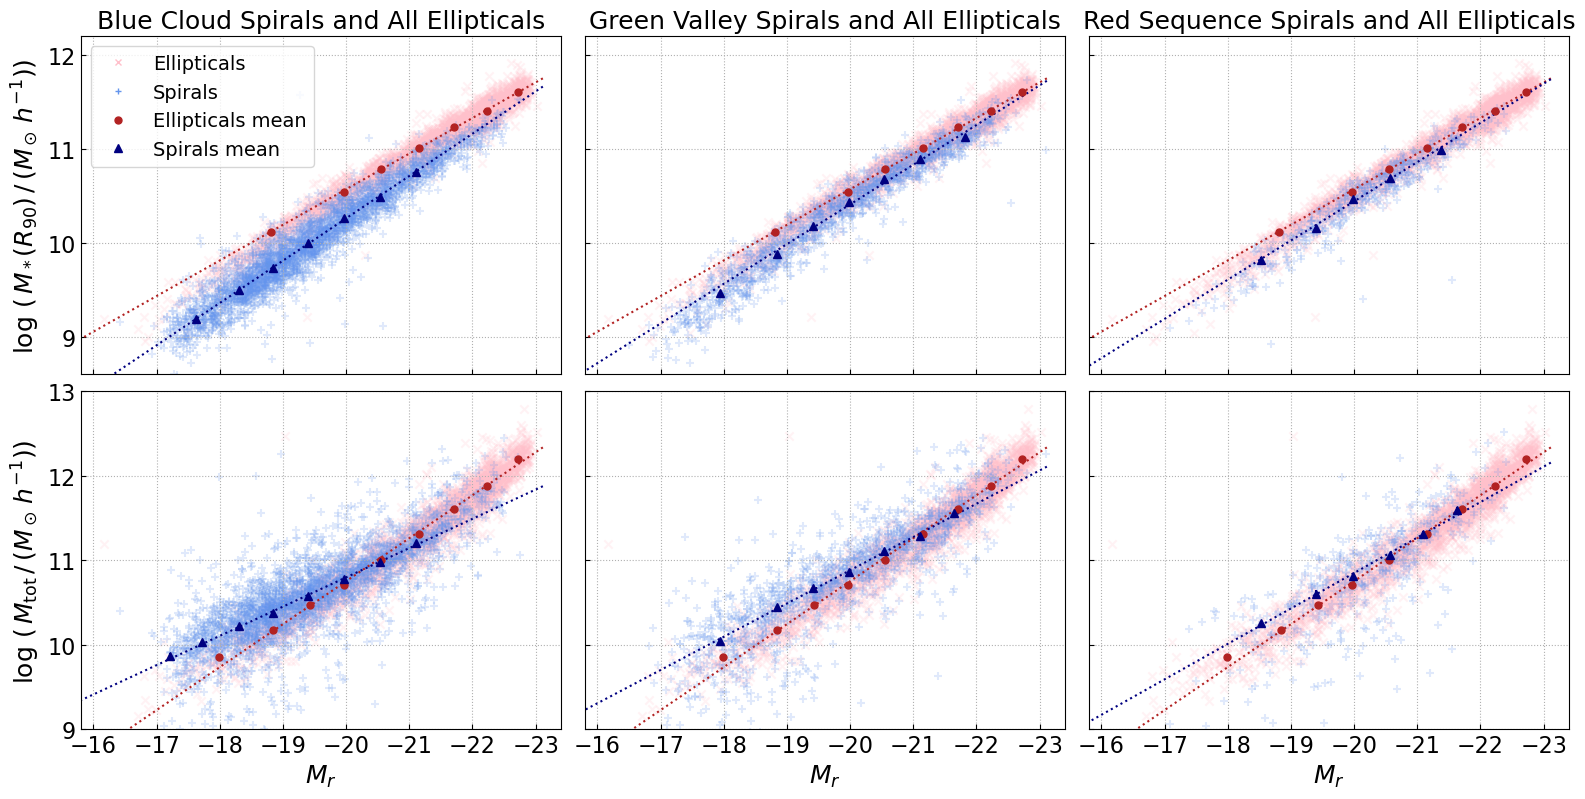

In [48]:
fig, ax = plt.subplots(2,3,sharex=True, sharey='row', figsize=(19.2,9))

# label plots
ax[0,0].set_title('Blue Cloud Spirals and All Ellipticals',fontsize=18)
ax[0,1].set_title('Green Valley Spirals and All Ellipticals',fontsize=18)
ax[0,2].set_title('Red Sequence Spirals and All Ellipticals', fontsize=18)
ax[0,0].set_ylabel(r'$\log\,(\,M_*(R_{90})\,/\,(M_\odot\,h^{-1}))$',fontsize=18)
ax[1,0].set_ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$',fontsize=18)

ax[0,0].set_yticks(np.arange(9,13,1))
ax[1,0].set_yticks(np.arange(9,14,1))
ax[1,0].set_ylim(9,13)
ax[0,0].set_ylim(8.6, 12.2)
ax[0,0].set_yticks(np.arange(9,13,1))
ax[1,0].set_yticks(np.arange(9,14,1))
rs = np.linspace(-23.2,-17.2,100)


for i in range(0,2):
    for j in range(0,3):
        ax[i,j].tick_params( axis='both', direction='in', labelsize=16)
        ax[i,j].grid( linestyle=':')


for i in range(0,3):

    ax[1,i].set_xlabel(r'$M_r$', fontsize=18)
    
    ax[1,i].set_xticks(np.arange(-23,-15,1))
    ax[1,i].set_xlim(-15.8, -23.4)
    
    ax[0,i].scatter(ellipticals['rabsmag'], ellipticals['e_M_star_R90_h'], color='pink', marker='x', alpha=0.2)
    ax[0,i].errorbar(e_mr_mstar_ctrs, e_mstar_avg, color='firebrick', yerr=e_mstar_sig, 
                 marker='o', linestyle='none', markersize=5, )
    ax[0,i].plot(mr_bins, e_mstar_popt[0]*mr_bins + e_mstar_popt[1], color='firebrick', linestyle=':')

    
    ax[1,i].scatter(ellipticals['rabsmag'], ellipticals['Mvir'], color='pink', marker='x', alpha=0.2)
    ax[1,i].errorbar(e_mr_mtot_ctrs,e_mtot_avg, color='firebrick', yerr=e_mtot_sig, 
                 marker='o',linestyle='none', markersize=5, )
    ax[1,i].plot(mr_bins, e_mtot_popt[0]*mr_bins + e_mtot_popt[1], color='firebrick', linestyle=':')




legend_elements = [Line2D([0], [0], marker='x', color='w', label='Ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='Spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=5),
                  Line2D([0], [0], marker='o', color='w', label='Ellipticals mean',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=5),
                  Line2D([0], [0], marker='^', color='w', label='Spirals mean',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6)]


ax[0,0].legend(handles=legend_elements,fontsize=14)



ax[0,0].scatter(blue_spirals['rabsmag'], blue_spirals['M90_disk_h'], color='cornflowerblue', marker='+', alpha=0.2)
ax[0,0].errorbar(bs_mr_mstar_ctrs, bs_mstar_avg, color='navy', yerr=bs_mstar_sig, 
                 marker='^',linestyle='none', markersize=6,)
ax[0,0].plot(mr_bins, bs_mstar_popt[0]*mr_bins + bs_mstar_popt[1], color='navy', linestyle=':')




ax[0,1].scatter(green_spirals['rabsmag'], green_spirals['M90_disk_h'], color='cornflowerblue', marker='+', alpha=0.2)
ax[0,1].errorbar(gs_mr_mstar_ctrs, gs_mstar_avg, color='navy', yerr=gs_mstar_sig, 
                 marker='^',linestyle='none', markersize=6,)
ax[0,1].plot(mr_bins, gs_mstar_popt[0]*mr_bins + gs_mstar_popt[1], color='navy', linestyle=':')





ax[0,2].scatter(red_spirals['rabsmag'], red_spirals['M90_disk_h'], color='cornflowerblue', marker='+', alpha=0.2)
ax[0,2].errorbar(rs_mr_mstar_ctrs,rs_mstar_avg, color='navy', yerr=rs_mstar_sig, 
                 marker='^',linestyle='none', markersize=6,)
ax[0,2].plot(mr_bins, rs_mstar_popt[0]*mr_bins + rs_mstar_popt[1], color='navy', linestyle=':')



ax[1,0].scatter(blue_spirals['rabsmag'], blue_spirals['M_R90'], color='cornflowerblue', marker='+', alpha=0.2, label='blue cloud spirals')
ax[1,0].errorbar(bs_mr_mtot_ctrs, bs_mtot_avg, color='navy', yerr=bs_mtot_sig, 
                 marker='^', label='blue cloud spiral median',linestyle='none', markersize=6,)
ax[1,0].plot(mr_bins, bs_mtot_popt[0]*mr_bins + bs_mtot_popt[1], color='navy', linestyle=':')



ax[1,1].scatter(green_spirals['rabsmag'], green_spirals['M_R90'], color='cornflowerblue', marker='+', alpha=0.2, label='blue cloud spirals')
ax[1,1].errorbar(gs_mr_mtot_ctrs, gs_mtot_avg, color='navy', yerr=gs_mtot_sig, 
                 marker='^', label='blue cloud spiral median',linestyle='none', markersize=6,)
ax[1,1].plot(mr_bins, gs_mtot_popt[0]*mr_bins + gs_mtot_popt[1], color='navy', linestyle=':')



ax[1,2].scatter(red_spirals['rabsmag'], red_spirals['M_R90'], color='cornflowerblue', marker='+', alpha=0.2, label='red sequence spirals')
ax[1,2].errorbar(rs_mr_mtot_ctrs, rs_mtot_avg, color='navy', yerr=rs_mtot_sig, 
                 marker='^', label='red sequence spiral median',linestyle='none', markersize=6,)
ax[1,2].plot(mr_bins, rs_mtot_popt[0]*mr_bins + rs_mtot_popt[1], color='navy', linestyle=':')

fig.subplots_adjust(wspace=0.05, hspace=0.05)
fig.savefig(plot_dir + 'Mtot_Mstar_Mr_CMDspiral_ellipticals.png', bbox_inches='tight')

## pipe3d modeled vs NSA

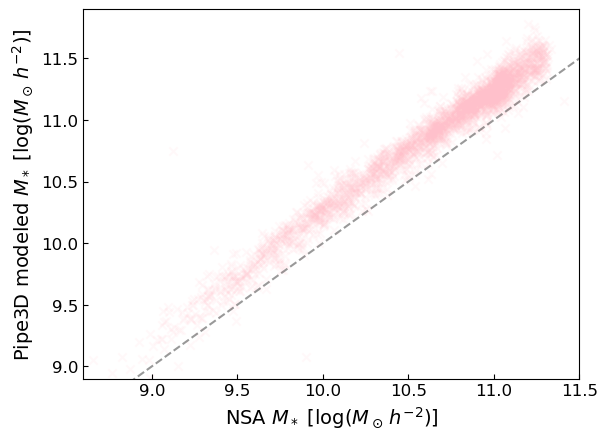

In [49]:
plt.scatter(ellipticals['nsa_elpetro_log_mass'], ellipticals['e_M_star_R90'] + np.log10(0.73**2), color='pink', alpha=0.1, marker='x')
plt.plot([8,12.5],[8,12.5], color='k', alpha=0.4, linestyle='--')
plt.xlim(8.6,11.5)
plt.ylim(8.9,11.9)
plt.tick_params( axis='both', direction='in', labelsize=12)

plt.xlabel(r'NSA $M_*$ $[\log(M_\odot\,h^{-2})]$', fontsize=14)
plt.ylabel(r'Pipe3D modeled $M_*$ $[\log(M_\odot\,h^{-2})]$', fontsize=14)
plt.savefig(plot_dir + 'nsa_pipe3d_model_mstar_compare.png')

In [50]:
print(ma.mean(ellipticals['e_M_star_R90']+ np.log10(0.73**2) - ellipticals['nsa_elpetro_log_mass']))
print(ma.median(ellipticals['e_M_star_R90']+ np.log10(0.73**2) - ellipticals['nsa_elpetro_log_mass']))

0.24552363692992502
0.24911255337619131


## MaNGA IllustrisTNG matches

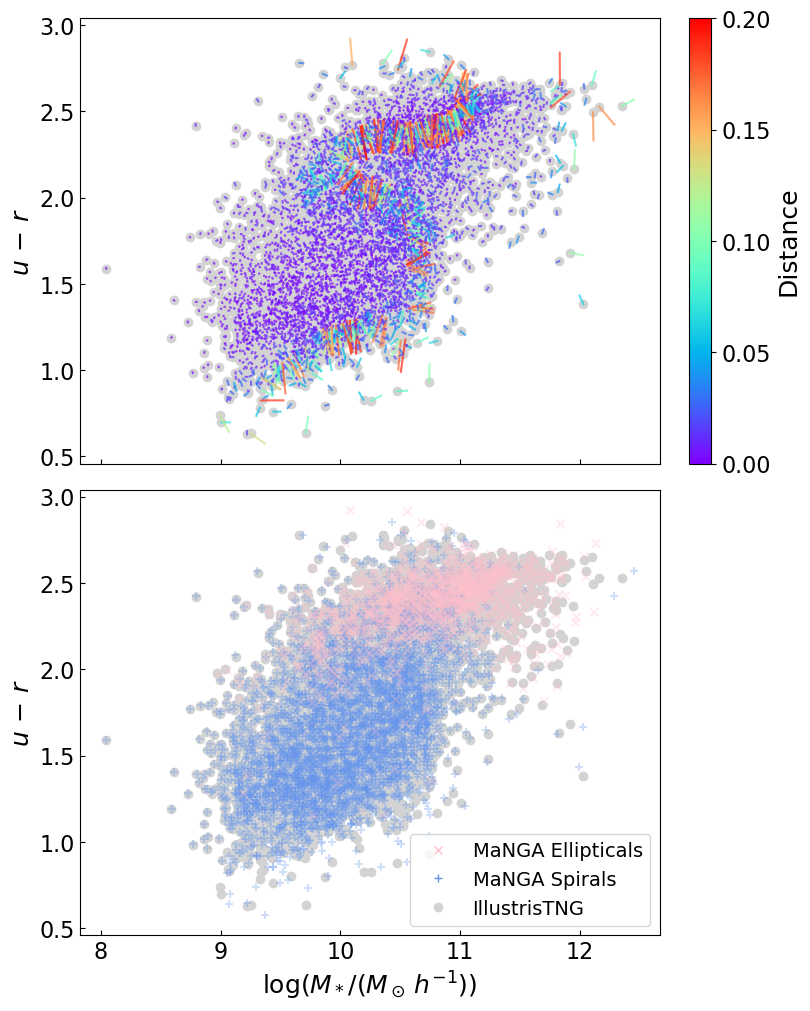

In [160]:
fig, ax = plt.subplots(2,1, figsize=(8,10), sharex=True, layout='compressed')
cmap = plt.get_cmap('rainbow')
ax[0].scatter(i_sample['illustris_Mstar_Sal'], i_sample['illustris_u_r'], marker='o', color='lightgrey')
for i in range(len(i_sample)):
    ax[0].plot([i_sample['sphd_M_star_h'][i],i_sample['illustris_Mstar_Sal'][i]],
                     [i_sample['nsa_u_r'][i],i_sample['illustris_u_r'][i]], 
                     alpha=0.7,color=cmap(i_sample['illustris_dist'][i]/0.2)
                    )
cbar = fig.colorbar(cm.ScalarMappable(norm=matplotlib.colors.Normalize(0, 0.2), cmap='rainbow'),
             ax=ax[0], orientation='vertical', label='distance', ticks=[0,0.05,0.1,0.15,0.2])
cbar.set_label('Distance', size=18)
ax[0].set_ylabel(r'$u\, -\, r$', size=18)
ax[1].set_ylabel(r'$u\, -\, r$', size=18)
ax[1].set_xlabel(r'$\log(M_*/(M_\odot\, h^{-1}))$', size=18)

ax[0].tick_params( axis='both', direction='in', labelsize=16)
ax[1].tick_params( axis='both', direction='in', labelsize=16)
cbar.ax.tick_params(labelsize=16) 


ax[1].scatter(i_sample['illustris_Mstar_Sal'], i_sample['illustris_u_r'], marker='o', color='lightgrey')
ax[1].scatter(i_sample[i_sample['spiral_mask']==1]['sphd_M_star_h'], i_sample[i_sample['spiral_mask']==1]['nsa_u_r'],
              marker='+', color='cornflowerblue', alpha=0.3)
ax[1].scatter(i_sample[i_sample['elliptical_mask']==1]['sphd_M_star_h'], i_sample[i_sample['elliptical_mask']==1]['nsa_u_r'],
              marker='x', color='pink', alpha=0.3)


legend_elements = [Line2D([0], [0], marker='x', color='w', label='MaNGA Ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=6),
                   Line2D([0], [0], marker='+', color='w', label='MaNGA Spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=6),
                  Line2D([0], [0], marker='o', color='w', label='IllustrisTNG',
                          markeredgecolor='lightgrey', markerfacecolor='lightgrey', markersize=6)]


ax[1].legend(handles=legend_elements,fontsize=14)
plt.savefig(plot_dir + '/TNGmatch/IllustrisTNG_matching.png', bbox_inches='tight')

## Mstar vs Mtot for matches

In [52]:
s_match = master_table[np.logical_and(master_table['spiral_mask']==1, master_table['illustris_match']>=0)]
e_match = master_table[np.logical_and(master_table['elliptical_mask']==1, master_table['illustris_match']>=0)]

In [53]:
min_mstar = np.min([np.min(s_match['sphd_M_star_h']), np.min(e_match['sphd_M_star_h']),
                    np.min(s_match['illustris_Mstar_Sal']), np.max(e_match['illustris_Mstar_Sal'])])
max_mstar = np.max([np.max(s_match['sphd_M_star_h']), np.max(e_match['sphd_M_star_h']),
                    np.max(s_match['illustris_Mstar_Sal']), np.max(e_match['illustris_Mstar_Sal'])])

mstar_bins = np.linspace(min_mstar, max_mstar+0.01, 15)

#### manga ellipticals

In [54]:
# ellipticals
e_mstar_ctrs = []
e_mtot = []
e_mstar_bins = mstar_bins
e_mstar_bins = np.concatenate((mstar_bins[:1], mstar_bins[6:-3], mstar_bins[-1:]))

indices = np.digitize(e_match['sphd_M_star_h'], e_mstar_bins, right=True)

for i in range(1,len(e_mstar_bins)):
    
    e_mtot.append(e_match['Mvir'][indices==i])
    e_mstar_ctrs.append(np.mean(e_match['sphd_M_star_h'][indices==i]))


e_mtot_avg, e_mtot_sig = fit_to_gaussian(e_mtot, plot_dir = plot_dir + '/TNGmatch/e_mtot_mstar_manga/', plot_name='e_Mtot_Mstar', xlab=r'$M_{\rm tot}$',
                                        plot_bins=e_mstar_bins, bin_lab=r'$M_*$')

# fit da lines

e_mtot_popt, e_mtot_pcov = curve_fit(lin_fit, e_mstar_ctrs, 
                                       e_mtot_avg, sigma=e_mtot_sig)

print(e_mtot_popt, np.sqrt(e_mtot_pcov[0,0]), np.sqrt(e_mtot_pcov[1,1]))

[ 1.18563875 -1.79924674] 0.052181043853692134 0.5595823534314447


In [55]:
# write data to a file 
f = open(plot_dir + '/TNGmatch/e_mtot_mstar_manga/data.txt', 'x')
f.write('e_mstar_centers \n')
f.write(str(e_mstar_ctrs) + '\n')
f.write('e_mstar_mtot_avgs \n')
f.write(str(e_mtot_avg)+ '\n')
f.write('e_mstar_mtot_sigs \n')
f.write(str(e_mtot_sig)+ '\n')

f.write('slope \n')
f.write(str(e_mtot_popt[0]) + ' +- ' + str(np.sqrt(e_mtot_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(e_mtot_popt[1]) + ' +- ' + str(np.sqrt(e_mtot_pcov[1,1]))+ '\n')
f.close()



#### tng ellipticals

In [58]:
# ellipticals
ie_mstar_ctrs = []
ie_mtot = []
ie_mstar_bins = mstar_bins
ie_mstar_bins = np.concatenate((mstar_bins[:1], mstar_bins[7:-3], mstar_bins[-1:]))

indices = np.digitize(e_match['illustris_Mstar_Sal'], ie_mstar_bins, right=True)

for i in range(1,len(ie_mstar_bins)):
    
    ie_mtot.append(e_match['illustris_MR90'][indices==i])
    ie_mstar_ctrs.append(np.mean(e_match['illustris_Mstar_Sal'][indices==i]))


ie_mtot_avg, ie_mtot_sig = fit_to_gaussian(ie_mtot, plot_dir = plot_dir + '/TNGmatch/e_mtot_mstar_tng/', plot_name='e_Mtot_Mstar', xlab=r'$M_{\rm tot}$',
                                          plot_bins=e_mstar_bins, bin_lab=r'$M_*$')

# fit da lines

ie_mtot_popt, ie_mtot_pcov = curve_fit(lin_fit, ie_mstar_ctrs, 
                                       ie_mtot_avg, sigma=ie_mtot_sig)

print(ie_mtot_popt, np.sqrt(ie_mtot_pcov[0,0]), np.sqrt(ie_mtot_pcov[1,1]))

[ 1.16666657 -1.59030589] 0.0659635176983512 0.7110235808762515


In [59]:
# write data to a file 
f = open(plot_dir + '/TNGmatch/e_mtot_mstar_tng/data.txt', 'x')
f.write('ie_mstar_centers \n')
f.write(str(ie_mstar_ctrs) + '\n')
f.write('ie_mstar_mtot_avgs \n')
f.write(str(ie_mtot_avg)+ '\n')
f.write('ie_mstar_mtot_sigs \n')
f.write(str(ie_mtot_sig)+ '\n')

f.write('slope \n')
f.write(str(ie_mtot_popt[0]) + ' +- ' + str(np.sqrt(ie_mtot_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(ie_mtot_popt[1]) + ' +- ' + str(np.sqrt(ie_mtot_pcov[1,1]))+ '\n')
f.close()


#### manga spirals

In [60]:
# spirals
s_mstar_ctrs = []
s_mtot = []
s_mstar_bins = mstar_bins
s_mstar_bins = np.concatenate((mstar_bins[:1], mstar_bins[4:-5], mstar_bins[-1:]))

indices = np.digitize(s_match['sphd_M_star_h'], s_mstar_bins, right=True)

for i in range(1,len(s_mstar_bins)):
    
    s_mtot.append(s_match['M_R90'][indices==i])
    s_mstar_ctrs.append(np.mean(s_match['sphd_M_star_h'][indices==i]))


s_mtot_avg, s_mtot_sig = fit_to_gaussian(s_mtot, plot_dir = plot_dir + '/TNGmatch/s_mtot_mstar_manga/', plot_name='s_Mtot_Mstar', xlab=r'$M_{\rm tot}$',
                                        plot_bins=s_mstar_bins, bin_lab=r'$M_*$')

# fit da lines

s_mtot_popt, s_mtot_pcov = curve_fit(lin_fit, s_mstar_ctrs, 
                                       s_mtot_avg, sigma=s_mtot_sig)

print(s_mtot_popt, np.sqrt(s_mtot_pcov[0,0]), np.sqrt(s_mtot_pcov[1,1]))

[0.74489108 3.08860021] 0.03537374247958995 0.3588294885477219


In [61]:
# write data to a file 
f = open(plot_dir + '/TNGmatch/s_mtot_mstar_manga/data.txt', 'x')
f.write('s_mstar_centers \n')
f.write(str(s_mstar_ctrs) + '\n')
f.write('s_mstar_mtot_avgs \n')
f.write(str(s_mtot_avg)+ '\n')
f.write('s_mstar_mtot_sigs \n')
f.write(str(s_mtot_sig)+ '\n')

f.write('slope \n')
f.write(str(s_mtot_popt[0]) + ' +- ' + str(np.sqrt(s_mtot_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(s_mtot_popt[1]) + ' +- ' + str(np.sqrt(s_mtot_pcov[1,1]))+ '\n')
f.close()



#### tng spirals

In [62]:
# spirals
is_mstar_ctrs = []
is_mtot = []
is_mstar_bins = mstar_bins
is_mstar_bins = np.concatenate((mstar_bins[:1], mstar_bins[3:-5], mstar_bins[-1:]))

indices = np.digitize(s_match['illustris_Mstar_Sal'], is_mstar_bins, right=True)

for i in range(1,len(is_mstar_bins)):
    
    is_mtot.append(s_match['illustris_MR90'][indices==i])
    is_mstar_ctrs.append(np.mean(s_match['illustris_Mstar_Sal'][indices==i]))


is_mtot_avg, is_mtot_sig = fit_to_gaussian(is_mtot, plot_dir = plot_dir + '/TNGmatch/s_mtot_mstar_tng/', plot_name='s_Mtot_Mstar', xlab=r'$M_{\rm tot}$',
                                          plot_bins=is_mstar_bins, bin_lab=r'$M_*$')

# fit da lines

is_mtot_popt, is_mtot_pcov = curve_fit(lin_fit, is_mstar_ctrs, 
                                       is_mtot_avg, sigma=is_mtot_sig)

print(is_mtot_popt, np.sqrt(is_mtot_pcov[0,0]), np.sqrt(is_mtot_pcov[1,1]))

[0.71250192 3.3744974 ] 0.03732817051910673 0.3787499275741628


In [63]:
# write data to a file 
f = open(plot_dir + '/TNGmatch/s_mtot_mstar_tng/data.txt', 'x')
f.write('is_mstar_centers \n')
f.write(str(is_mstar_ctrs) + '\n')
f.write('is_mstar_mtot_avgs \n')
f.write(str(is_mtot_avg)+ '\n')
f.write('is_mstar_mtot_sigs \n')
f.write(str(is_mtot_sig)+ '\n')

f.write('slope \n')
f.write(str(is_mtot_popt[0]) + ' +- ' + str(np.sqrt(is_mtot_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(is_mtot_popt[1]) + ' +- ' + str(np.sqrt(is_mtot_pcov[1,1]))+ '\n')
f.close()



### plot

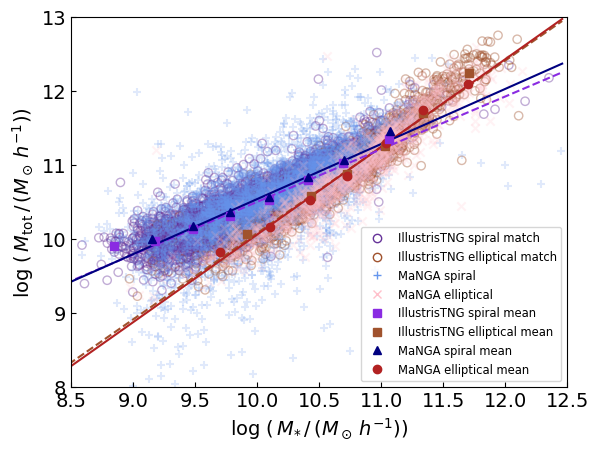

In [64]:
plt.scatter(s_match['illustris_Mstar_Sal'], s_match['illustris_MR90'],
           color='rebeccapurple', alpha=0.4, marker='o', facecolor='none')
plt.scatter(e_match['illustris_Mstar_Sal'], e_match['illustris_MR90'],
           color='sienna', alpha=0.4, marker='o', facecolor='none')
plt.scatter(s_match['sphd_M_star_h'], s_match['M_R90'],
           color='cornflowerblue',marker='+', alpha=0.2)
plt.scatter(e_match['sphd_M_star_h'], e_match['Mvir'],
           color='pink',marker='x', alpha=0.2)

plt.xlim(8.5,12.5)
# plt.plot([7,14],[7,14], linestyle='--', color='k', alpha=0.4)
plt.ylim(8,13)


legend_elements = [Line2D([0], [0], marker='o', color='w', label='IllustrisTNG spiral match',
                          markeredgecolor='rebeccapurple', markerfacecolor='none', markersize=6),
                   Line2D([0], [0], marker='o', color='w', label='IllustrisTNG elliptical match',
                          markeredgecolor='sienna', markerfacecolor='none', markersize=6),
                  Line2D([0], [0], marker='+', color='w', label='MaNGA spiral',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=6),
                  Line2D([0], [0], marker='x', color='w', label='MaNGA elliptical',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=6),
                  Line2D([0], [0], marker='s', color='w', label='IllustrisTNG spiral mean',
                          markeredgecolor='blueviolet', markerfacecolor='blueviolet', markersize=6),
                   Line2D([0], [0], marker='s', color='w', label='IllustrisTNG elliptical mean',
                          markeredgecolor='sienna', markerfacecolor='sienna', markersize=6),
                  Line2D([0], [0], marker='^', color='w', label='MaNGA spiral mean',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6),
                  Line2D([0], [0], marker='o', color='w', label='MaNGA elliptical mean',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=6)]

# plot fits

plt.errorbar(ie_mstar_ctrs, ie_mtot_avg, yerr=ie_mtot_sig, linestyle='none', marker='s', color='sienna')
plt.errorbar(e_mstar_ctrs, e_mtot_avg, yerr=e_mtot_sig, linestyle='none', marker='o', color='firebrick')

plt.plot(mstar_bins, mstar_bins*ie_mtot_popt[0] + ie_mtot_popt[1], linestyle='--', color='sienna')
plt.plot(mstar_bins, mstar_bins*e_mtot_popt[0] + e_mtot_popt[1], linestyle='-', color='firebrick')


plt.errorbar(is_mstar_ctrs, is_mtot_avg, yerr=is_mtot_sig, linestyle='none', marker='s', color='blueviolet')
plt.errorbar(s_mstar_ctrs, s_mtot_avg, yerr=s_mtot_sig, linestyle='none', marker='^', color='navy')

plt.plot(mstar_bins, mstar_bins*is_mtot_popt[0] + is_mtot_popt[1], linestyle='--', color='blueviolet')
plt.plot(mstar_bins, mstar_bins*s_mtot_popt[0] + s_mtot_popt[1], linestyle='-', color='navy')

plt.tick_params( axis='both', direction='in',labelsize=14)



plt.ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
plt.xlabel(r'$\log\,(\,M_{*}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)

plt.legend(handles=legend_elements, fontsize='small')
plt.savefig(plot_dir + '/TNGmatch/mtot_mstar_illustris.png')

## MCMC BTFR for matched samples

In [65]:
v_eff_bins = np.linspace(np.min([np.log10(np.min(ellipticals['v_eff'])), np.log10(np.min(HI_spirals['V_R90']))]),
                         np.max([np.log10(np.max(ellipticals['v_eff'])), np.log10(np.max(HI_spirals['V_R90']))]),
                         15)

In [66]:
min_mvis = np.min([np.min(HI_s_match['Mstar_MHI_h']), np.min(HI_s_match['illustris_Mstar_MHI_h']),
                   np.min(e_match['sphd_M_star_h']), np.min(e_match['illustris_Mstar_Sal'])])

max_mvis = np.max([np.max(HI_s_match['Mstar_MHI_h']), np.max(HI_s_match['illustris_Mstar_MHI_h']),
                   np.max(e_match['sphd_M_star_h']), np.max(e_match['illustris_Mstar_Sal'])])

mvis_bins = np.linspace(min_mvis, max_mvis + 0.1, 15)

#### MaNGA ellipticals

In [67]:
e_veff = []
e_veff_ctr = []
e_mvis_bins = mvis_bins
e_mvis_bins = np.concatenate((mvis_bins[:0], mvis_bins[4:-4], mvis_bins[-1:]))
indices = np.digitize(e_match['sphd_M_star_h'], e_mvis_bins)

for i in range(1, len(e_mvis_bins)):

    e_veff.append(np.log10(e_match['v_eff'])[indices==i])
    e_veff_ctr.append(np.mean(e_match['sphd_M_star_h'][indices==i]))

e_mvis_veff_avg, e_mvis_veff_sig = fit_to_gaussian(e_veff, plot_dir = plot_dir +'/BTFR/ellipticals_manga/', 
                                                         plot_name='e_v_eff_mvis', bin_lab=r'$M_{\rm vis}$',
                                                  plot_bins=e_mvis_bins, xlab=r'$V_{\rm eff}$')



In [68]:
x0 = np.random.uniform(low=[-10,-10], high=[10,10], size=(32,2))
nwalkers, ndim = x0.shape

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=(np.array(e_veff_ctr), e_mvis_veff_avg, e_mvis_veff_sig))
state = sampler.run_mcmc(x0, 10000, progress='notebook')

  0%|          | 0/10000 [00:00<?, ?it/s]

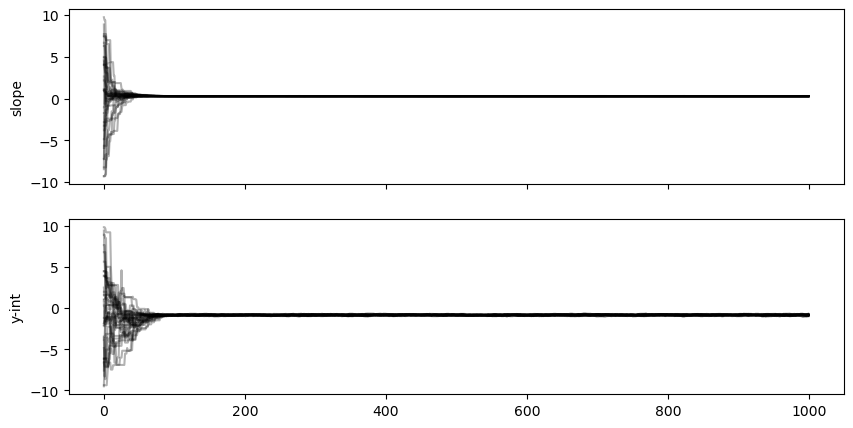

In [69]:
fig, axes = plt.subplots(2,1, figsize=(10,5), sharex=True, gridspec_kw={'hspace':0.2})
samples = sampler.get_chain()
labels = ['slope', 'y-int']
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:1000, :, i], 'k', alpha=0.3)
    ax.set_ylabel(labels[i])


In [70]:
tau = sampler.get_autocorr_time()
flat_samples = sampler.get_chain(discard=100, thin=int(np.max(tau)), flat=True)

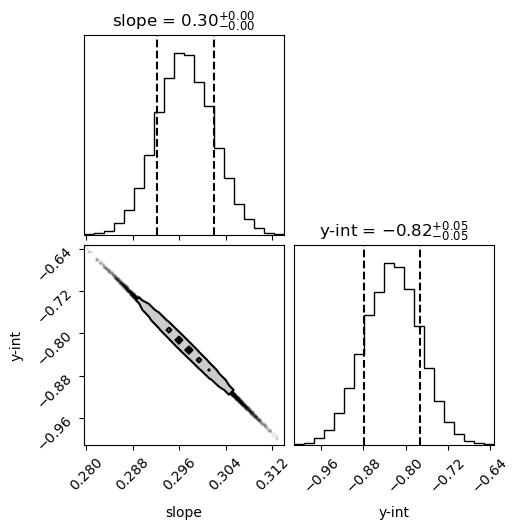

In [71]:
fig = corner.corner(flat_samples, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                    show_titles=1,
                    title_quantiles = [0.16,0.5,0.84]
                   # plot_density=1
                   )

In [72]:
flat_samples_flip = np.array([1/flat_samples[:,0], -flat_samples[:,1]/flat_samples[:,0]]).transpose()

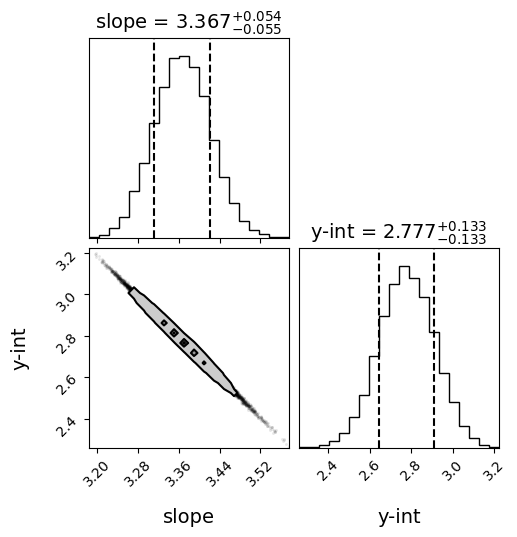

In [73]:
fig = corner.corner(flat_samples_flip, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                    show_titles=1,
                    title_quantiles = [0.16,0.5,0.84],
                    title_fmt='.3f',
                    label_kwargs={'fontsize':14},
                    title_kwargs={'fontsize':14},
                    
                   # plot_density=1
                    
                   )

# plt.tick_params(labelsize=14)


plt.savefig(plot_dir + '/BTFR/ellipticals_manga/' + 'manga_ellipticals_corner.png', bbox_inches='tight')

In [74]:
e_slope = np.percentile(flat_samples_flip[:,0],50)
e_slope_bounds = [np.percentile(flat_samples_flip[:,0],16), np.percentile(flat_samples_flip[:,0],84)]
e_yint = np.percentile(flat_samples_flip[:,1],50)
e_yint_bounds = [np.percentile(flat_samples_flip[:,1],16), np.percentile(flat_samples_flip[:,1],84)]
e_chi2 = chi2_norm(lin_fit(np.array(e_veff_ctr), np.percentile(flat_samples[:,0],50), np.percentile(flat_samples[:,1],50)), e_mvis_veff_avg, e_mvis_veff_sig, 2)

In [75]:
bs = np.linspace(-2,0,10000)
e_chi2_fixed = np.zeros(len(bs))
for i in range(len(bs)):
    e_chi2_fixed[i] = chi2_norm(lin_fit(np.array(e_veff_ctr), 0.25, bs[i]), e_mvis_veff_avg, e_mvis_veff_sig, 1)

In [76]:
e_yint_fixed = bs[np.argmin(e_chi2_fixed)]
e_chi2_fixed_min = np.min(e_chi2_fixed)
print(np.min(e_chi2_fixed))
print(bs[np.argmin(e_chi2_fixed)])

21.21180322256521
-0.30883088308830886


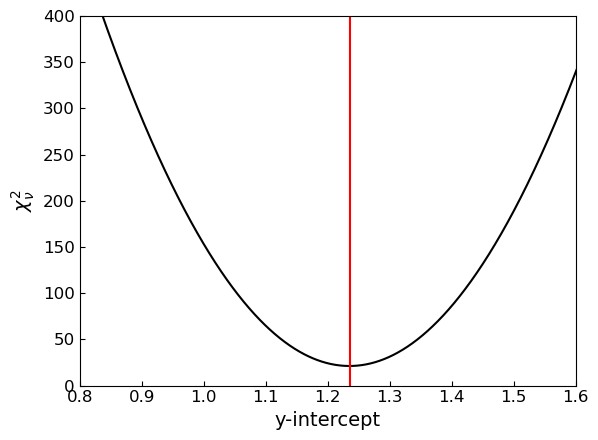

In [77]:
plt.plot(-bs/0.25, e_chi2_fixed, color='k')
plt.axvline(-e_yint_fixed/0.25, color='r', label=fr'Fixed slope, y-int= {-e_yint_fixed/0.25:.4f}, $\chi^2_\nu$ = {e_chi2_fixed_min:.4f}')
# plt.axvline(-e_yint/e_slope, color='g', linestyle=':', label=fr'Varying slope y-int= {-e_yint/e_slope:.4f}, $\chi^2_\nu$ = {e_chi2:.4f}')
# plt.legend()
plt.xlabel('y-intercept', fontsize=14)
plt.ylabel(r'$\chi^2_\nu$', fontsize=14)
plt.tick_params(axis='both', direction='in', labelsize=12)
# plt.title(f'slope = {1/e_slope:.4f}')
plt.xlim(0.8,1.6)
plt.ylim(0,400)
plt.savefig(plot_dir + '/BTFR/ellipticals_manga/' + 'manga_ellipticals_fixedslope.png', bbox_inches='tight')

In [78]:
# write data to a file 
f = open(plot_dir + '/BTFR/ellipticals_manga/data.txt', 'x')
f.write('e_veff_centers \n')
f.write(str(e_veff_ctr) + '\n')
f.write('e_mvis_avgs \n')
f.write(str(e_mvis_veff_avg)+ '\n')
f.write('e_mvis_sigs \n')
f.write(str(e_mvis_veff_sig)+ '\n')

f.write('MCMC slope \n')
f.write(str(e_slope) + str(e_slope_bounds-e_slope)+ '\n')
f.write('y-int \n')
f.write(str(e_yint) + str(e_yint_bounds-e_yint)+ '\n')
f.write('chi2 nu \n')
f.write(str(e_chi2) + '\n')

f.write('fixed slope 4 y-int \n')
f.write(str(-e_yint_fixed/0.25) + '\n')
f.write('chi2 nu \n')
f.write(str(e_chi2_fixed_min))


f.close()



#### Illustris ellipticals

In [79]:
ie_veff = []
ie_veff_ctr = []
ie_mvis_bins = mvis_bins
ie_mvis_bins = np.concatenate((mvis_bins[:0], mvis_bins[4:-4], mvis_bins[-1:]))
indices = np.digitize(e_match['illustris_Mstar_Sal'], ie_mvis_bins)

for i in range(1, len(ie_mvis_bins)):

    ie_veff.append(np.log10(e_match['v_eff'])[indices==i])
    ie_veff_ctr.append(np.mean(e_match['illustris_Mstar_Sal'][indices==i]))

ie_mvis_veff_avg, ie_mvis_veff_sig = fit_to_gaussian(ie_veff, plot_dir = plot_dir +'/BTFR/ellipticals_tng/', 
                                                         plot_name='e_v_eff_mvis', bin_lab=r'$M_{\rm vis}$',
                                                     plot_bins=ie_mvis_bins, xlab=r'$V_{\rm eff}$')



In [80]:
x0 = np.random.uniform(low=[-10,-10], high=[10,10], size=(32,2))
nwalkers, ndim = x0.shape

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=(np.array(ie_veff_ctr), ie_mvis_veff_avg, ie_mvis_veff_sig))
state = sampler.run_mcmc(x0, 10000, progress='notebook')

  0%|          | 0/10000 [00:00<?, ?it/s]

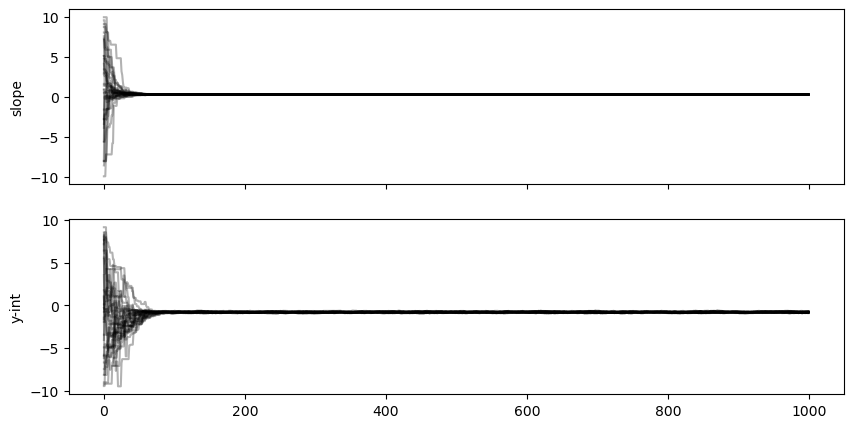

In [81]:
fig, axes = plt.subplots(2,1, figsize=(10,5), sharex=True, gridspec_kw={'hspace':0.2})
samples = sampler.get_chain()
labels = ['slope', 'y-int']
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:1000, :, i], 'k', alpha=0.3)
    ax.set_ylabel(labels[i])

In [82]:
tau = sampler.get_autocorr_time()
flat_samples = sampler.get_chain(discard=100, thin=int(np.max(tau)), flat=True)

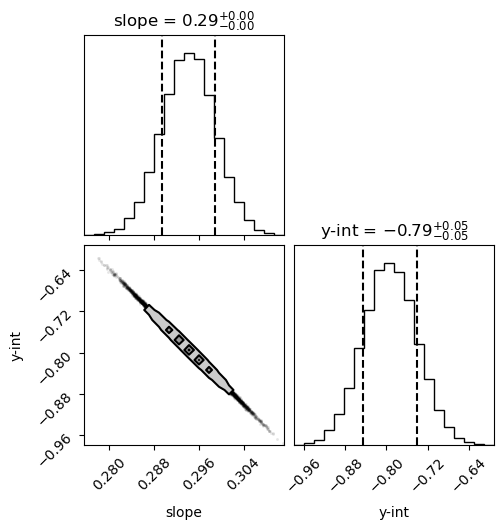

In [83]:
fig = corner.corner(flat_samples, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                    show_titles=1,
                    title_quantiles = [0.16,0.5,0.84]
                   # plot_density=1
                   )

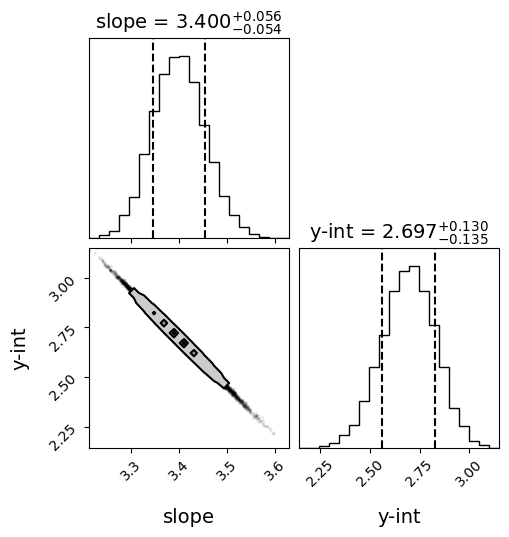

In [84]:
flat_samples_flip = np.array([1/flat_samples[:,0], -flat_samples[:,1]/flat_samples[:,0]]).transpose()
fig = corner.corner(flat_samples_flip, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                    show_titles=1,
                    title_quantiles = [0.16,0.5,0.84],
                    title_fmt='.3f',
                    label_kwargs={'fontsize':14},
                    title_kwargs={'fontsize':14},
                   # plot_density=1
                    
                   )

plt.savefig(plot_dir + '/BTFR/ellipticals_tng/' + 'tng_ellipticals_corner.png', bbox_inches='tight')

In [85]:
ie_slope = np.percentile(flat_samples_flip[:,0],50)
ie_slope_bounds = [np.percentile(flat_samples_flip[:,0],16), np.percentile(flat_samples_flip[:,0],84)]
ie_yint = np.percentile(flat_samples_flip[:,1],50)
ie_yint_bounds = [np.percentile(flat_samples_flip[:,1],16), np.percentile(flat_samples_flip[:,1],84)]
ie_chi2 = chi2_norm(lin_fit(np.array(e_veff_ctr), np.percentile(flat_samples[:,0],50), np.percentile(flat_samples[:,1],50)), ie_mvis_veff_avg, ie_mvis_veff_sig, 2)

In [86]:
bs = np.linspace(-2,0,10000)
ie_chi2_fixed = np.zeros(len(bs))
for i in range(len(bs)):
    ie_chi2_fixed[i] = chi2_norm(lin_fit(np.array(ie_veff_ctr), 0.25, bs[i]), ie_mvis_veff_avg, ie_mvis_veff_sig, 1)

In [87]:
ie_yint_fixed = bs[np.argmin(ie_chi2_fixed)]
ie_chi2_fixed_min = np.min(ie_chi2_fixed)
print(np.min(ie_chi2_fixed))
print(bs[np.argmin(ie_chi2_fixed)])

20.091763657632338
-0.3086308630863086


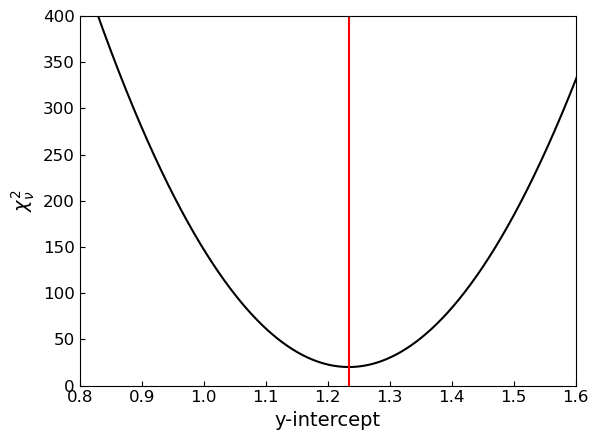

In [88]:
plt.plot(-bs/0.25, ie_chi2_fixed, color='k')
plt.axvline(-ie_yint_fixed/0.25, color='r', label=fr'Fixed slope, y-int= {-ie_yint_fixed/0.25:.4f}, $\chi^2_\nu$ = {ie_chi2_fixed_min:.4f}')
# plt.axvline(-e_yint/e_slope, color='g', linestyle=':', label=fr'Varying slope y-int= {-e_yint/e_slope:.4f}, $\chi^2_\nu$ = {e_chi2:.4f}')
# plt.legend()
plt.xlabel('y-intercept', fontsize=14)
plt.ylabel(r'$\chi^2_\nu$', fontsize=14)
plt.tick_params(axis='both', direction='in', labelsize=12)
# plt.title(f'slope = {1/e_slope:.4f}')
plt.xlim(0.8,1.6)
plt.ylim(0,400)
plt.savefig(plot_dir + '/BTFR/ellipticals_tng/' + 'tng_ellipticals_fixedslope.png', bbox_inches='tight')

In [89]:
# write data to a file 
f = open(plot_dir + '/BTFR/ellipticals_tng/data.txt', 'x')
f.write('e_veff_centers \n')
f.write(str(ie_veff_ctr) + '\n')
f.write('e_mvis_avgs \n')
f.write(str(ie_mvis_veff_avg)+ '\n')
f.write('e_mvis_sigs \n')
f.write(str(ie_mvis_veff_sig)+ '\n')

f.write('MCMC slope \n')
f.write(str(ie_slope) + str(ie_slope_bounds-ie_slope)+ '\n')
f.write('y-int \n')
f.write(str(ie_yint) + str(ie_yint_bounds-ie_yint)+ '\n')
f.write('chi2 nu \n')
f.write(str(ie_chi2) + '\n')

f.write('fixed slope 4 y-int \n')
f.write(str(-ie_yint_fixed/0.25) + '\n')
f.write('chi2 nu \n')
f.write(str(ie_chi2_fixed_min))


f.close()



#### MaNGA spirals

In [90]:
s_veff = []
s_veff_ctr = []
s_mvis_bins = mvis_bins
s_mvis_bins = np.concatenate((mvis_bins[:1], mvis_bins[3:-6], mvis_bins[-1:]))
indices = np.digitize(HI_s_match['Mstar_MHI_h'], s_mvis_bins)

for i in range(1, len(s_mvis_bins)):

    s_veff.append(np.log10(HI_s_match['V_R90'])[indices==i])
    s_veff_ctr.append(np.mean(HI_s_match['Mstar_MHI_h'][indices==i]))

s_mvis_veff_avg, s_mvis_veff_sig = fit_to_gaussian(s_veff, plot_dir = plot_dir +'/BTFR/spirals_manga/', 
                                                         plot_name='s_v_eff_mvis', bin_lab=r'$M_{\rm vis}$',
                                                  plot_bins=s_mvis_bins, xlab=r'$V_{\rm eff}$')



In [91]:
x0 = np.random.uniform(low=[-10,-10], high=[10,10], size=(32,2))
nwalkers, ndim = x0.shape

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=(np.array(s_veff_ctr), s_mvis_veff_avg, s_mvis_veff_sig))
state = sampler.run_mcmc(x0, 10000, progress='notebook')

  0%|          | 0/10000 [00:00<?, ?it/s]

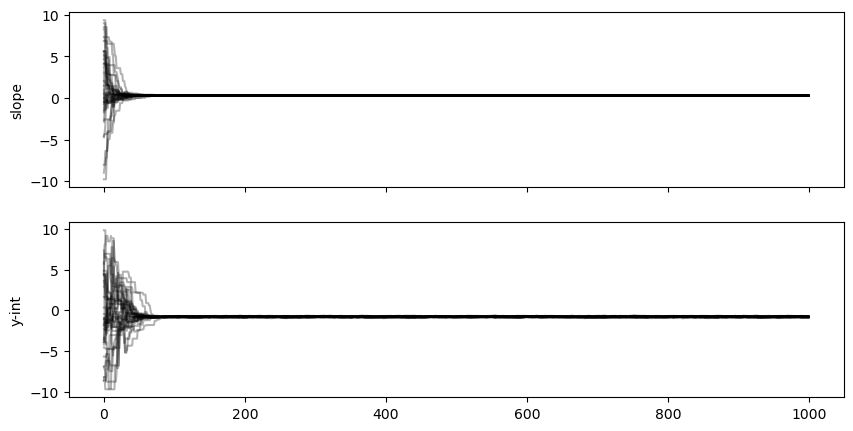

In [92]:
fig, axes = plt.subplots(2,1, figsize=(10,5), sharex=True, gridspec_kw={'hspace':0.2})
samples = sampler.get_chain()
labels = ['slope', 'y-int']
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:1000, :, i], 'k', alpha=0.3)
    ax.set_ylabel(labels[i])
    

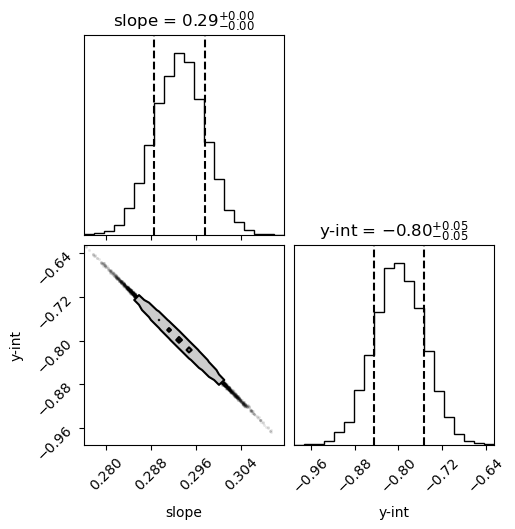

In [93]:
tau = sampler.get_autocorr_time()
flat_samples = sampler.get_chain(discard=100, thin=int(np.max(tau)), flat=True)
fig = corner.corner(flat_samples, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                    show_titles=1,
                    title_quantiles = [0.16,0.5,0.84]
                   # plot_density=1
                   )

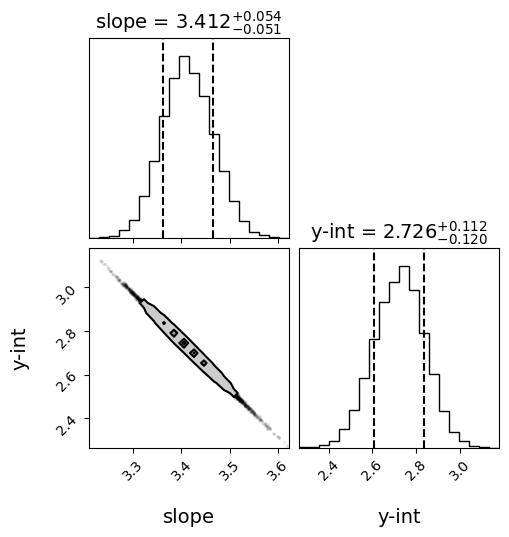

In [94]:
flat_samples_flip = np.array([1/flat_samples[:,0], -flat_samples[:,1]/flat_samples[:,0]]).transpose()
fig = corner.corner(flat_samples_flip, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                    show_titles=1,
                    title_quantiles = [0.16,0.5,0.84],
                   title_fmt='.3f',
                    label_kwargs={'fontsize':14},
                    title_kwargs={'fontsize':14},
                   # plot_density=1
                    
                   )

plt.savefig(plot_dir + '/BTFR/spirals_manga/' + 'manga_spirals_corner.png', bbox_inches='tight')

In [95]:
s_slope = np.percentile(flat_samples_flip[:,0],50)
s_slope_bounds = [np.percentile(flat_samples_flip[:,0],16), np.percentile(flat_samples_flip[:,0],84)]
s_yint = np.percentile(flat_samples_flip[:,1],50)
s_yint_bounds = [np.percentile(flat_samples_flip[:,1],16), np.percentile(flat_samples_flip[:,1],84)]
s_chi2 = chi2_norm(lin_fit(np.array(s_veff_ctr), np.percentile(flat_samples[:,0],50), np.percentile(flat_samples[:,1],50)), s_mvis_veff_avg, s_mvis_veff_sig, 2)

In [96]:
bs = np.linspace(-2,0,10000)
s_chi2_fixed = np.zeros(len(bs))
for i in range(len(bs)):
    s_chi2_fixed[i] = chi2_norm(lin_fit(np.array(s_veff_ctr), 0.25, bs[i]), s_mvis_veff_avg, s_mvis_veff_sig, 1)

In [97]:
s_yint_fixed = bs[np.argmin(s_chi2_fixed)]
s_chi2_fixed_min = np.min(s_chi2_fixed)
print(np.min(s_chi2_fixed))
print(bs[np.argmin(s_chi2_fixed)])

16.472475963593737
-0.35823582358235817


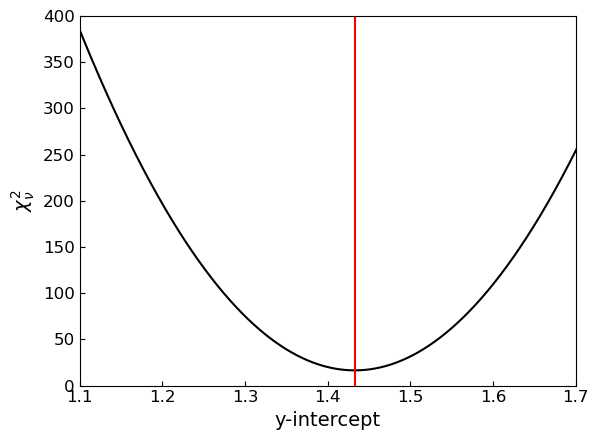

In [98]:
plt.plot(-bs/0.25, s_chi2_fixed, color='k')
plt.axvline(-s_yint_fixed/0.25, color='r', label=fr'Fixed slope, y-int= {-s_yint_fixed/0.25:.4f}, $\chi^2_\nu$ = {s_chi2_fixed_min:.4f}')
# plt.axvline(-e_yint/e_slope, color='g', linestyle=':', label=fr'Varying slope y-int= {-e_yint/e_slope:.4f}, $\chi^2_\nu$ = {e_chi2:.4f}')
# plt.legend()
plt.xlabel('y-intercept', fontsize=14)
plt.ylabel(r'$\chi^2_\nu$', fontsize=14)
plt.tick_params(axis='both', direction='in', labelsize=12)
# plt.title(f'slope = {1/e_slope:.4f}')
plt.xlim(1.1,1.7)
plt.ylim(0,400)
plt.savefig(plot_dir + '/BTFR/spirals_manga/' + 'manga_spirals_fixedslope.png', bbox_inches='tight')

In [99]:
# write data to a file 
f = open(plot_dir + '/BTFR/spirals_manga/data.txt', 'x')
f.write('s_veff_centers \n')
f.write(str(s_veff_ctr) + '\n')
f.write('s_mvis_avgs \n')
f.write(str(s_mvis_veff_avg)+ '\n')
f.write('s_mvis_sigs \n')
f.write(str(s_mvis_veff_sig)+ '\n')

f.write('MCMC slope \n')
f.write(str(s_slope) + str(s_slope_bounds-s_slope)+ '\n')
f.write('y-int \n')
f.write(str(s_yint) + str(s_yint_bounds-s_yint)+ '\n')
f.write('chi2 nu \n')
f.write(str(s_chi2) + '\n')

f.write('fixed slope 4 y-int \n')
f.write(str(-s_yint_fixed/0.25) + '\n')
f.write('chi2 nu \n')
f.write(str(s_chi2_fixed_min))


f.close()



#### Illustris spirals

In [100]:
is_veff = []
is_veff_ctr = []
is_mvis_bins = mvis_bins
is_mvis_bins = np.concatenate((mvis_bins[:1], mvis_bins[3:-6], mvis_bins[-1:]))
indices = np.digitize(HI_s_match['illustris_Mstar_MHI_h'], is_mvis_bins)

for i in range(1, len(is_mvis_bins)):

    is_veff.append(np.log10(HI_s_match['illustris_Vmax'])[indices==i])
    is_veff_ctr.append(np.mean(HI_s_match['illustris_Mstar_MHI_h'][indices==i]))

is_mvis_veff_avg, is_mvis_veff_sig = fit_to_gaussian(is_veff, plot_dir = plot_dir +'/BTFR/spirals_tng/',
                                                         plot_name='s_v_eff_mvis', bin_lab=r'$M_{\rm vis}$',
                                                        plot_bins=is_mvis_bins, xlab=r'$V_{\rm eff}$')



In [101]:
x0 = np.random.uniform(low=[-10,-10], high=[10,10], size=(32,2))
nwalkers, ndim = x0.shape

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=(np.array(is_veff_ctr), is_mvis_veff_avg, is_mvis_veff_sig))
state = sampler.run_mcmc(x0, 10000, progress='notebook')

  0%|          | 0/10000 [00:00<?, ?it/s]

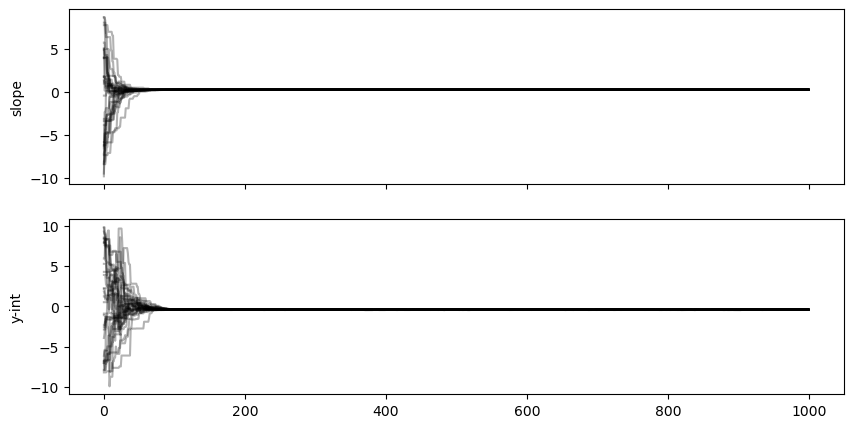

In [102]:
fig, axes = plt.subplots(2,1, figsize=(10,5), sharex=True, gridspec_kw={'hspace':0.2})
samples = sampler.get_chain()
labels = ['slope', 'y-int']
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:1000, :, i], 'k', alpha=0.3)
    ax.set_ylabel(labels[i])
    

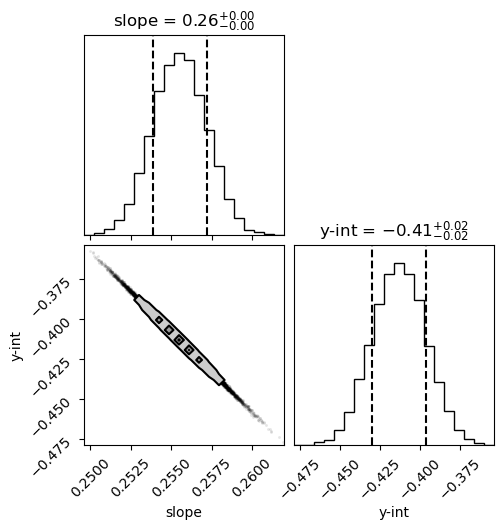

In [103]:
tau = sampler.get_autocorr_time()
flat_samples = sampler.get_chain(discard=100, thin=int(np.max(tau)), flat=True)
fig = corner.corner(flat_samples, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                     show_titles=1,
                    title_quantiles = [0.16,0.5,0.84]
                   # plot_density=1
                   )

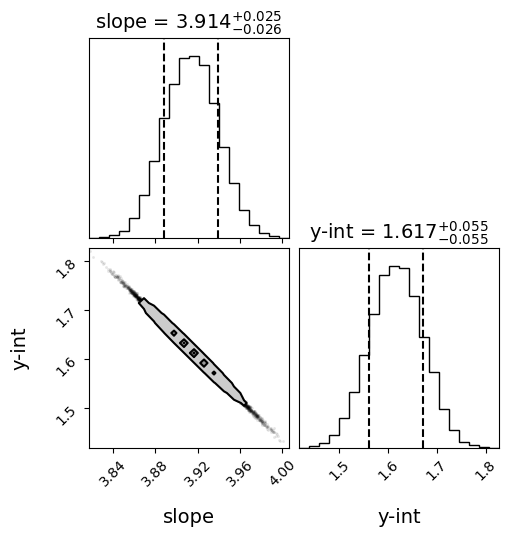

In [104]:
flat_samples_flip = np.array([1/flat_samples[:,0], -flat_samples[:,1]/flat_samples[:,0]]).transpose()
fig = corner.corner(flat_samples_flip, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                    show_titles=1,
                    title_quantiles = [0.16,0.5,0.84],
                    title_fmt='.3f',
                    label_kwargs={'fontsize':14},
                    title_kwargs={'fontsize':14},
                   # plot_density=1
                    
                   )

plt.savefig(plot_dir + '/BTFR/spirals_tng/' + 'tng_spirals_corner.png', bbox_inches='tight')

In [105]:
is_slope = np.percentile(flat_samples_flip[:,0],50)
is_slope_bounds = [np.percentile(flat_samples_flip[:,0],16), np.percentile(flat_samples_flip[:,0],84)]
is_yint = np.percentile(flat_samples_flip[:,1],50)
is_yint_bounds = [np.percentile(flat_samples_flip[:,1],16), np.percentile(flat_samples_flip[:,1],84)]
is_chi2 = chi2_norm(lin_fit(np.array(is_veff_ctr), np.percentile(flat_samples[:,0],50), np.percentile(flat_samples[:,1],50)), is_mvis_veff_avg, is_mvis_veff_sig, 2)

In [106]:
bs = np.linspace(-2,0,10000)
is_chi2_fixed = np.zeros(len(bs))
for i in range(len(bs)):
    is_chi2_fixed[i] = chi2_norm(lin_fit(np.array(is_veff_ctr), 0.25, bs[i]), is_mvis_veff_avg, is_mvis_veff_sig, 1)

In [107]:
is_yint_fixed = bs[np.argmin(is_chi2_fixed)]
is_chi2_fixed_min = np.min(is_chi2_fixed)
print(np.min(is_chi2_fixed))
print(bs[np.argmin(is_chi2_fixed)])

19.708999665524818
-0.3578357835783579


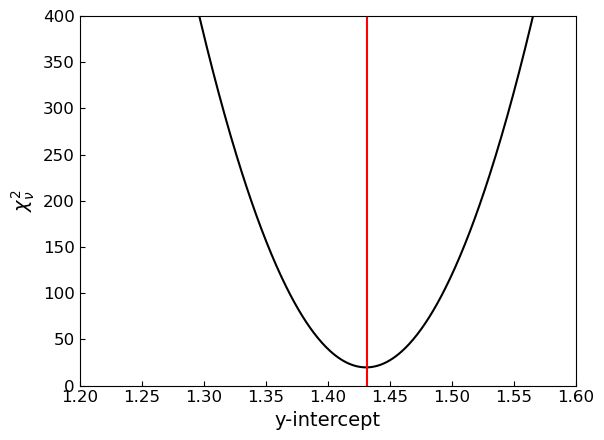

In [108]:
plt.plot(-bs/0.25, is_chi2_fixed, color='k')
plt.axvline(-is_yint_fixed/0.25, color='r', label=fr'Fixed slope, y-int= {-is_yint_fixed/0.25:.4f}, $\chi^2_\nu$ = {is_chi2_fixed_min:.4f}')
# plt.axvline(-e_yint/e_slope, color='g', linestyle=':', label=fr'Varying slope y-int= {-e_yint/e_slope:.4f}, $\chi^2_\nu$ = {e_chi2:.4f}')
# plt.legend()
plt.xlabel('y-intercept', fontsize=14)
plt.ylabel(r'$\chi^2_\nu$', fontsize=14)
plt.tick_params(axis='both', direction='in', labelsize=12)
# plt.title(f'slope = {1/e_slope:.4f}')
plt.xlim(1.2,1.6)
plt.ylim(0,400)
plt.savefig(plot_dir + '/BTFR/spirals_tng/' + 'tng_spirals_fixedslope.png', bbox_inches='tight')

In [109]:
# write data to a file 
f = open(plot_dir + '/BTFR/spirals_tng/data.txt', 'x')
f.write('s_veff_centers \n')
f.write(str(is_veff_ctr) + '\n')
f.write('s_mvis_avgs \n')
f.write(str(is_mvis_veff_avg)+ '\n')
f.write('s_mvis_sigs \n')
f.write(str(is_mvis_veff_sig)+ '\n')

f.write('MCMC slope \n')
f.write(str(is_slope) + str(is_slope_bounds-is_slope)+ '\n')
f.write('y-int \n')
f.write(str(is_yint) + str(is_yint_bounds-is_yint)+ '\n')
f.write('chi2 nu \n')
f.write(str(is_chi2) + '\n')

f.write('fixed slope 4 y-int \n')
f.write(str(-is_yint_fixed/0.25) + '\n')
f.write('chi2 nu \n')
f.write(str(is_chi2_fixed_min))


f.close()



### combined lines, just means

In [112]:
ms = np.linspace(1,20,1000)
vs = np.linspace(0,5,1000)

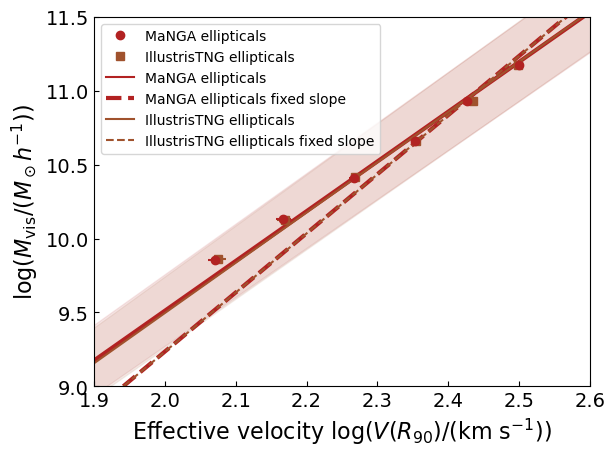

In [113]:
plt.fill_between(vs, vs*e_slope_bounds[1] + e_yint_bounds[1],vs*e_slope_bounds[0] + e_yint_bounds[0], color='firebrick', alpha=0.1)
plt.fill_between(vs, vs*ie_slope_bounds[1] + ie_yint_bounds[1],vs*ie_slope_bounds[0] + ie_yint_bounds[0], color='sienna', alpha=0.1)



plt.errorbar(ie_mvis_veff_avg, ie_veff_ctr, xerr=ie_mvis_veff_sig,
            linestyle='none', marker='s', color='sienna')
plt.errorbar(e_mvis_veff_avg, e_veff_ctr, xerr=e_mvis_veff_sig, 
             linestyle='none', marker='o', color='firebrick')



# plt.plot(ms*0.25 + e_yint, ms, color='firebrick')
plt.plot(vs, vs*e_slope + e_yint, color='firebrick', linewidth=3)
plt.plot(ms*0.25 + e_yint_fixed, ms, color='firebrick', linestyle='--', linewidth=3)
plt.plot(vs, vs*ie_slope + ie_yint, color='sienna')
plt.plot(ms*0.25 + ie_yint_fixed, ms, color='sienna', linestyle='--')


legend_elements = [Line2D([0], [0], marker='o', color='w', label='MaNGA ellipticals',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=6),
                   Line2D([0], [0], marker='s', color='w', label='IllustrisTNG ellipticals',
                          markeredgecolor='sienna', markerfacecolor='sienna', markersize=6),
                   Line2D([0], [0], marker='none', color='firebrick', label='MaNGA ellipticals',
                          markeredgecolor='firebrick', markersize=6),
                   Line2D([0], [0], marker='none', color='firebrick', label='MaNGA ellipticals fixed slope',
                          markeredgecolor='firebrick', linestyle='--',markersize=6, linewidth=3),
                   Line2D([0], [0], marker='none', color='sienna', label='IllustrisTNG ellipticals',
                          markeredgecolor='sienna', markerfacecolor='sienna', markersize=6),
                   Line2D([0], [0], marker='none', color='sienna', label='IllustrisTNG ellipticals fixed slope',
                          markeredgecolor='sienna', markerfacecolor='sienna', linestyle='--',markersize=6),]
                   
#                   # Line2D([0], [0], marker='s', color='w', label='IllustrisTNG spiral mean',
#                   #         markeredgecolor='blueviolet', markerfacecolor='blueviolet', markersize=6),
#                   #  Line2D([0], [0], marker='s', color='w', label='IllustrisTNG elliptical mean',
#                   #         markeredgecolor='sienna', markerfacecolor='sienna', markersize=6),
#                   # Line2D([0], [0], marker='^', color='w', label='MaNGA spiral mean',
#                   #         markeredgecolor='navy', markerfacecolor='navy', markersize=6),
#                   # Line2D([0], [0], marker='o', color='w', label='MaNGA elliptical mean',
#                   #         markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=6)
#                   ]

plt.legend(handles=legend_elements)


plt.xlim(1.9,2.6)
plt.ylim(9,11.5)

plt.tick_params( axis='both', direction='in', labelsize=14)
plt.xlabel(r'Effective velocity $\log(V(R_{90})/(\text{km s}^{-1}))$', fontsize=16)
plt.ylabel(r'$\log(M_{\rm vis}/(M_\odot h^{-1}))$', fontsize=16)

plt.savefig(plot_dir + '/BTFR/' + 'ellipticals_BTFR_slopes_v2.png', bbox_inches='tight')

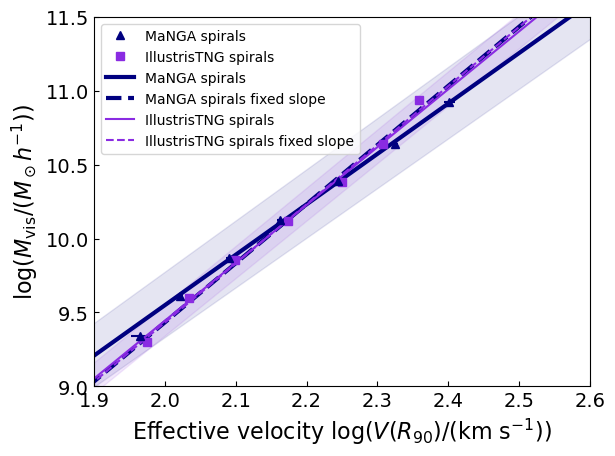

In [114]:

plt.fill_between(vs, vs*s_slope_bounds[1] + s_yint_bounds[1],vs*s_slope_bounds[0] + s_yint_bounds[0], color='navy', alpha=0.1)
plt.fill_between(vs, vs*is_slope_bounds[1] + is_yint_bounds[1],vs*is_slope_bounds[0] + is_yint_bounds[0], color='blueviolet', alpha=0.1)




plt.errorbar(is_mvis_veff_avg, is_veff_ctr, xerr=is_mvis_veff_sig,
            linestyle='none', marker='s', color='blueviolet')
plt.errorbar(s_mvis_veff_avg, s_veff_ctr, xerr=s_mvis_veff_sig, 
             linestyle='none', marker='^', color='navy')



plt.plot(vs, vs*s_slope + s_yint, color='navy', linewidth=3)
plt.plot(ms*0.25 + s_yint_fixed, ms, color='navy', linestyle='--', linewidth=3)
plt.plot(vs, vs*is_slope + is_yint, color='blueviolet', linestyle='-')
plt.plot(ms*0.25 + is_yint_fixed, ms, color='blueviolet',linestyle='--')

legend_elements = [Line2D([0], [0], marker='^', color='w', label='MaNGA spirals',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6),
                   Line2D([0], [0], marker='s', color='w', label='IllustrisTNG spirals',
                          markeredgecolor='blueviolet', markerfacecolor='blueviolet', markersize=6),
                   Line2D([0], [0], marker='none', color='navy', label='MaNGA spirals',
                          markeredgecolor='navy', markersize=6, linewidth=3),
                   Line2D([0], [0], marker='none', color='navy', label='MaNGA spirals fixed slope',
                          markeredgecolor='navy', linestyle='--',markersize=6, linewidth=3),
                   Line2D([0], [0], marker='none', color='blueviolet', label='IllustrisTNG spirals',
                          markeredgecolor='blueviolet', markerfacecolor='blueviolet', markersize=6),
                   Line2D([0], [0], marker='none', color='blueviolet', label='IllustrisTNG spirals fixed slope',
                          markeredgecolor='blueviolet', linestyle='--',markersize=6),
                  ]




plt.legend(handles=legend_elements)


plt.xlim(1.9,2.6)
plt.ylim(9,11.5)

plt.tick_params( axis='both', direction='in', labelsize=14)
plt.xlabel(r'Effective velocity $\log(V(R_{90})/(\text{km s}^{-1}))$', fontsize=16)
plt.ylabel(r'$\log(M_{\rm vis}/(M_\odot h^{-1}))$', fontsize=16)
plt.savefig(plot_dir + '/BTFR/' + 'spirals_BTFR_slopes_v2.png', bbox_inches='tight')

### BTFR scatter plots

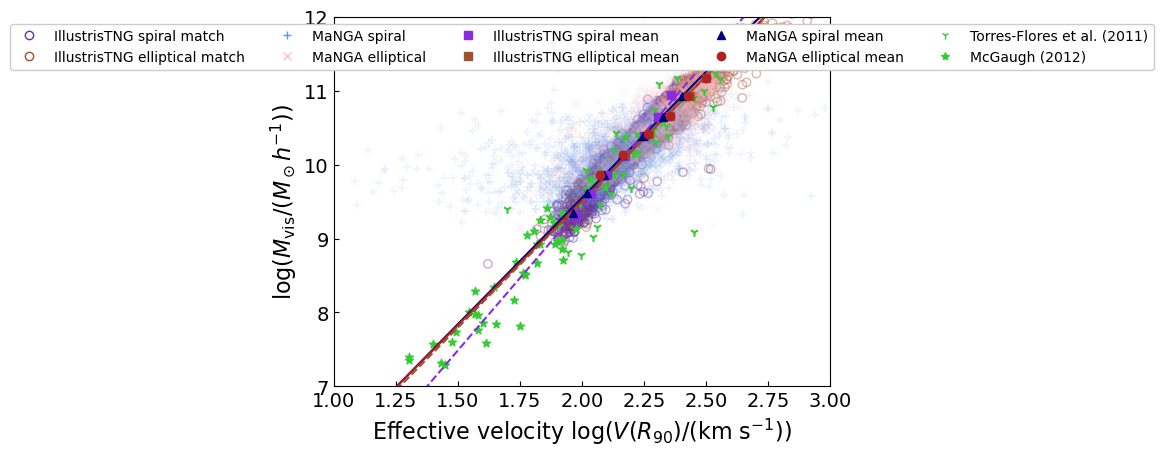

In [179]:
plt.scatter(np.log10(HI_s_match['illustris_Vmax']), HI_s_match['illustris_Mstar_MHI_h'], marker='o', facecolor='none',
            color='rebeccapurple', alpha=0.4, label='Spirals')
plt.scatter(np.log10(e_match['illustris_Vmax']), e_match['illustris_Mstar_Sal'], marker='o', facecolor='none',
            color='sienna', alpha=0.4, label='Spirals')
plt.scatter(np.log10(HI_s_match['V_R90']), HI_s_match['Mstar_MHI_h'], marker='+', color='cornflowerblue', alpha=0.1, label='Spirals')

plt.scatter(np.log10(e_match['v_eff']), e_match['sphd_M_star_h'], marker='x', color='pink', alpha=0.1, label='Ellipticals')


plt.errorbar(is_mvis_veff_avg, is_veff_ctr, xerr=is_mvis_veff_sig, linestyle='none',
            marker='s', color='blueviolet')
plt.errorbar(ie_mvis_veff_avg, ie_veff_ctr, xerr=ie_mvis_veff_sig, linestyle='none',
            marker='s', color='sienna')
plt.errorbar(s_mvis_veff_avg, s_veff_ctr, xerr=s_mvis_veff_sig, linestyle='none',
            marker='^', color='navy')
plt.errorbar(e_mvis_veff_avg, e_veff_ctr, xerr=e_mvis_veff_sig, linestyle='none',
            marker='o', color='firebrick')




plt.plot(vs, vs*s_slope + s_yint, color='navy')
# plt.plot(ms*0.25 + s_yint_fixed, ms, color='navy', linestyle='--', linewidth=3)
plt.plot(vs, vs*is_slope + is_yint, color='blueviolet', linestyle='--')
# plt.plot(ms*0.25 + is_yint_fixed, ms, color='blueviolet',linestyle='--')
plt.plot(vs, vs*e_slope + e_yint, color='firebrick')
# plt.plot(ms*0.25 + e_yint_fixed, ms, color='firebrick', linestyle='--', linewidth=3)
plt.plot(vs, vs*ie_slope + ie_yint, color='sienna', linestyle='--')
# plt.plot(ms*0.25 + ie_yint_fixed, ms, color='sienna', linestyle='--')

plt.xlim(1,3)
plt.ylim(7,12)
plt.tick_params( axis='both', direction='in', labelsize=14)
plt.xlabel(r'Effective velocity $\log(V(R_{90})/(\text{km s}^{-1}))$', fontsize=16)
plt.ylabel(r'$\log(M_{\rm vis}/(M_\odot h^{-1}))$', fontsize=16)


plt.scatter(np.log10(mcg['V_f']), np.log10(10**mcg['Mstar'] + 10**mcg['Mg']) +np.log10(0.73), 
            marker='*', color='limegreen', label='McGaugh (2012)')
plt.scatter(np.log10(torflor['V_TF']), torflor['Mbar'] +np.log10(0.73), marker='1', color='limegreen', s=40, label='Torres-Flores et al. (2011)')

legend_elements = [Line2D([0], [0], marker='o', color='w', label='IllustrisTNG spiral match',
                          markeredgecolor='rebeccapurple', markerfacecolor='none', markersize=6),
                   Line2D([0], [0], marker='o', color='w', label='IllustrisTNG elliptical match',
                          markeredgecolor='sienna', markerfacecolor='none', markersize=6),
                  Line2D([0], [0], marker='+', color='w', label='MaNGA spiral',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=6),
                  Line2D([0], [0], marker='x', color='w', label='MaNGA elliptical',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=6),
                  Line2D([0], [0], marker='s', color='w', label='IllustrisTNG spiral mean',
                          markeredgecolor='blueviolet', markerfacecolor='blueviolet', markersize=6),
                   Line2D([0], [0], marker='s', color='w', label='IllustrisTNG elliptical mean',
                          markeredgecolor='sienna', markerfacecolor='sienna', markersize=6),
                  Line2D([0], [0], marker='^', color='w', label='MaNGA spiral mean',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6),
                  Line2D([0], [0], marker='o', color='w', label='MaNGA elliptical mean',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=6),
                  
                  Line2D([0], [0], marker='1', color='w', label='Torres-Flores et al. (2011)',
                          markeredgecolor='limegreen', markerfacecolor='limegreen', markersize=6),
                  
                  Line2D([0], [0], marker='*', color='w', label='McGaugh (2012)',
                          markeredgecolor='limegreen', markerfacecolor='limegreen', markersize=6),]

plt.legend(handles=legend_elements, loc='upper center', framealpha=1, ncols=5)
# plt.savefig(plot_dir + 'BTFR/BTFR_mstarhi_illustris.png', bbox_inches='tight')

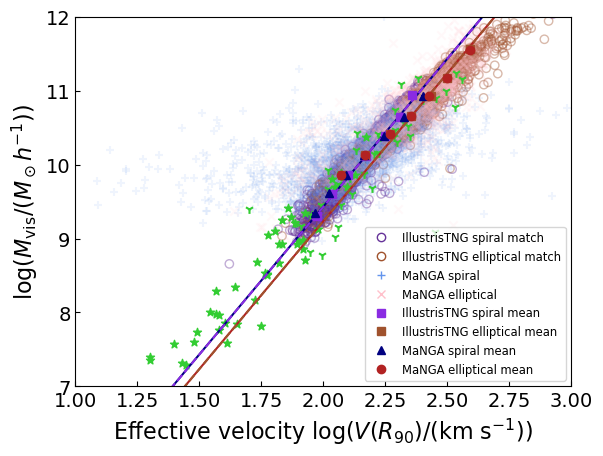

In [116]:
plt.scatter(np.log10(HI_s_match['illustris_Vmax']), HI_s_match['illustris_Mstar_MHI_h'], marker='o', facecolor='none',
            color='rebeccapurple', alpha=0.4, label='Spirals')
plt.scatter(np.log10(e_match['illustris_Vmax']), e_match['illustris_Mstar_Sal'], marker='o', facecolor='none',
            color='sienna', alpha=0.4, label='Spirals')
plt.scatter(np.log10(HI_s_match['V_R90']), HI_s_match['Mstar_MHI_h'], marker='+', color='cornflowerblue', alpha=0.1, label='Spirals')

plt.scatter(np.log10(e_match['v_eff']), e_match['sphd_M_star_h'], marker='x', color='pink', alpha=0.1, label='Ellipticals')


plt.errorbar(is_mvis_veff_avg, is_veff_ctr, xerr=is_mvis_veff_sig, linestyle='none',
            marker='s', color='blueviolet')
plt.errorbar(ie_mvis_veff_avg, ie_veff_ctr, xerr=ie_mvis_veff_sig, linestyle='none',
            marker='s', color='sienna')
plt.errorbar(s_mvis_veff_avg, s_veff_ctr, xerr=s_mvis_veff_sig, linestyle='none',
            marker='^', color='navy')
plt.errorbar(e_mvis_veff_avg, e_veff_ctr, xerr=e_mvis_veff_sig, linestyle='none',
            marker='o', color='firebrick')




# plt.plot(vs, vs*s_slope + s_yint, color='navy')
plt.plot(ms*0.25 + s_yint_fixed, ms, color='navy')
# plt.plot(vs, vs*is_slope + is_yint, color='blueviolet', linestyle='--')
plt.plot(ms*0.25 + is_yint_fixed, ms, color='blueviolet',linestyle='--')
# plt.plot(vs, vs*e_slope + e_yint, color='firebrick')
plt.plot(ms*0.25 + e_yint_fixed, ms, color='firebrick')
# plt.plot(vs, vs*ie_slope + ie_yint, color='sienna', linestyle='--')
plt.plot(ms*0.25 + ie_yint_fixed, ms, color='sienna', linestyle='--')

plt.xlim(1,3)
plt.ylim(7,12)
plt.tick_params( axis='both', direction='in', labelsize=14)
plt.xlabel(r'Effective velocity $\log(V(R_{90})/(\text{km s}^{-1}))$', fontsize=16)
plt.ylabel(r'$\log(M_{\rm vis}/(M_\odot h^{-1}))$', fontsize=16)


plt.scatter(np.log10(mcg['V_f']), np.log10(10**mcg['Mstar'] + 10**mcg['Mg']) +np.log10(0.73), 
            marker='*', color='limegreen', label='McGaugh (2012)')
plt.scatter(np.log10(torflor['V_TF']), torflor['Mbar'] +np.log10(0.73), marker='1', color='limegreen', s=40, label='Torres-Flores et al. (2011)')

legend_elements = [Line2D([0], [0], marker='o', color='w', label='IllustrisTNG spiral match',
                          markeredgecolor='rebeccapurple', markerfacecolor='none', markersize=6),
                   Line2D([0], [0], marker='o', color='w', label='IllustrisTNG elliptical match',
                          markeredgecolor='sienna', markerfacecolor='none', markersize=6),
                  Line2D([0], [0], marker='+', color='w', label='MaNGA spiral',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=6),
                  Line2D([0], [0], marker='x', color='w', label='MaNGA elliptical',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=6),
                  Line2D([0], [0], marker='s', color='w', label='IllustrisTNG spiral mean',
                          markeredgecolor='blueviolet', markerfacecolor='blueviolet', markersize=6),
                   Line2D([0], [0], marker='s', color='w', label='IllustrisTNG elliptical mean',
                          markeredgecolor='sienna', markerfacecolor='sienna', markersize=6),
                  Line2D([0], [0], marker='^', color='w', label='MaNGA spiral mean',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6),
                  Line2D([0], [0], marker='o', color='w', label='MaNGA elliptical mean',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=6)]
plt.legend(handles=legend_elements, fontsize='small')
plt.savefig(plot_dir + 'BTFR/BTFR_mstarhi_illustris_fixed_slope.png', bbox_inches='tight')

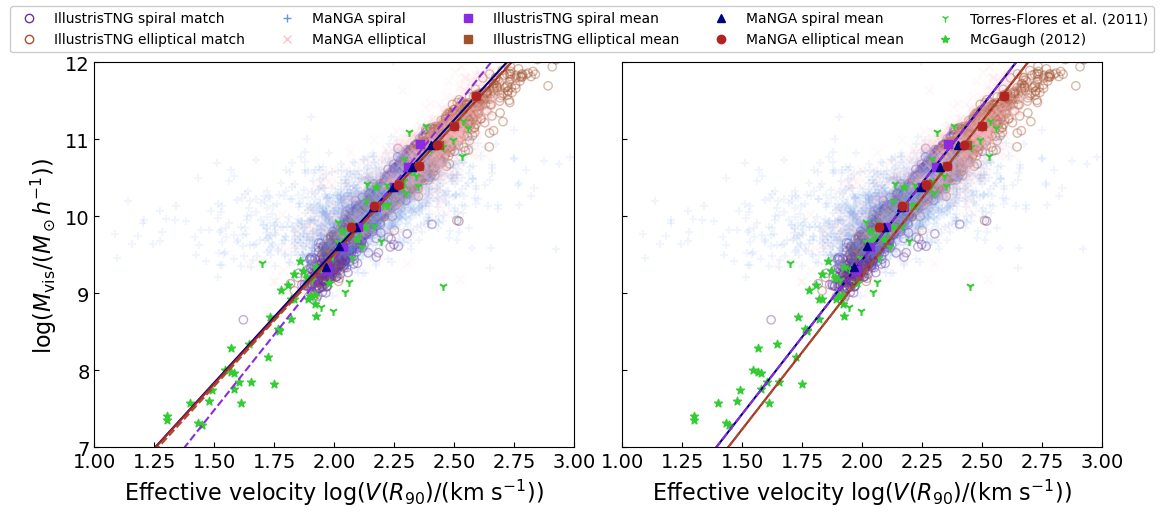

In [191]:
fig, ax  = plt.subplots(1,2, figsize=(13,5), sharey=True)

for i in range(2):

    ax[i].scatter(np.log10(HI_s_match['illustris_Vmax']), HI_s_match['illustris_Mstar_MHI_h'], marker='o', facecolor='none',
                color='rebeccapurple', alpha=0.4, label='Spirals')
    ax[i].scatter(np.log10(e_match['illustris_Vmax']), e_match['illustris_Mstar_Sal'], marker='o', facecolor='none',
                color='sienna', alpha=0.4, label='Spirals')
    ax[i].scatter(np.log10(HI_s_match['V_R90']), HI_s_match['Mstar_MHI_h'], marker='+', color='cornflowerblue', alpha=0.1, label='Spirals')
    
    ax[i].scatter(np.log10(e_match['v_eff']), e_match['sphd_M_star_h'], marker='x', color='pink', alpha=0.1, label='Ellipticals')


    ax[i].errorbar(is_mvis_veff_avg, is_veff_ctr, xerr=is_mvis_veff_sig, linestyle='none',
                marker='s', color='blueviolet')
    ax[i].errorbar(ie_mvis_veff_avg, ie_veff_ctr, xerr=ie_mvis_veff_sig, linestyle='none',
                marker='s', color='sienna')
    ax[i].errorbar(s_mvis_veff_avg, s_veff_ctr, xerr=s_mvis_veff_sig, linestyle='none',
                marker='^', color='navy')
    ax[i].errorbar(e_mvis_veff_avg, e_veff_ctr, xerr=e_mvis_veff_sig, linestyle='none',
                marker='o', color='firebrick')
    ax[i].set_xlim(1,3)
    ax[i].set_ylim(7,12)
    ax[i].tick_params( axis='both', direction='in', labelsize=14)
    ax[i].set_xlabel(r'Effective velocity $\log(V(R_{90})/(\text{km s}^{-1}))$', fontsize=16)

    ax[i].scatter(np.log10(mcg['V_f']), np.log10(10**mcg['Mstar'] + 10**mcg['Mg']) +np.log10(0.73), 
            marker='*', color='limegreen', label='McGaugh (2012)')
    ax[i].scatter(np.log10(torflor['V_TF']), torflor['Mbar'] +np.log10(0.73), marker='1', color='limegreen', s=40, label='Torres-Flores et al. (2011)')





ax[0].plot(vs, vs*s_slope + s_yint, color='navy')
ax[0].plot(vs, vs*is_slope + is_yint, color='blueviolet', linestyle='--')
ax[0].plot(vs, vs*e_slope + e_yint, color='firebrick')
ax[0].plot(vs, vs*ie_slope + ie_yint, color='sienna', linestyle='--')

ax[1].plot(ms*0.25 + s_yint_fixed, ms, color='navy')
ax[1].plot(ms*0.25 + is_yint_fixed, ms, color='blueviolet',linestyle='--')
ax[1].plot(ms*0.25 + e_yint_fixed, ms, color='firebrick')
ax[1].plot(ms*0.25 + ie_yint_fixed, ms, color='sienna', linestyle='--')


ax[0].set_ylabel(r'$\log(M_{\rm vis}/(M_\odot h^{-1}))$', fontsize=16)


legend_elements = [Line2D([0], [0], marker='o', color='w', label='IllustrisTNG spiral match',
                          markeredgecolor='rebeccapurple', markerfacecolor='none', markersize=6),
                   Line2D([0], [0], marker='o', color='w', label='IllustrisTNG elliptical match',
                          markeredgecolor='sienna', markerfacecolor='none', markersize=6),
                  Line2D([0], [0], marker='+', color='w', label='MaNGA spiral',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=6),
                  Line2D([0], [0], marker='x', color='w', label='MaNGA elliptical',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=6),
                  Line2D([0], [0], marker='s', color='w', label='IllustrisTNG spiral mean',
                          markeredgecolor='blueviolet', markerfacecolor='blueviolet', markersize=6),
                   Line2D([0], [0], marker='s', color='w', label='IllustrisTNG elliptical mean',
                          markeredgecolor='sienna', markerfacecolor='sienna', markersize=6),
                  Line2D([0], [0], marker='^', color='w', label='MaNGA spiral mean',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6),
                  Line2D([0], [0], marker='o', color='w', label='MaNGA elliptical mean',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=6),
                  
                  Line2D([0], [0], marker='1', color='w', label='Torres-Flores et al. (2011)',
                          markeredgecolor='limegreen', markerfacecolor='limegreen', markersize=6),
                  
                  Line2D([0], [0], marker='*', color='w', label='McGaugh (2012)',
                          markeredgecolor='limegreen', markerfacecolor='limegreen', markersize=6),]

fig.legend(handles=legend_elements, loc='upper center', framealpha=1, ncols=5)
fig.subplots_adjust(wspace=0.1, hspace=0.05)

# plt.tight_layout()
plt.savefig(plot_dir + 'BTFR/BTFR_mstarhi_illustris_combined.png', bbox_inches='tight')

## Full TNG BTFR

In [117]:
import illustris_python as il
import h5py
import tqdm


In [118]:
base_path = '/Users/nityaravi/Documents/Research/RotationCurves/data/IlustrisTNG/TNG100-1/'
fields = ['SubhaloFlag',  'SubhaloMassInRadType', 
          # 'SubhaloMass', 'SubhaloMassInHalfRad',
          'SubhaloVmax', 'SubhaloVmaxRad', 
          # 'SubhaloStellarPhotometricsMassInRad','SubhaloStellarPhotometricsRad', 'SubhaloHalfmassRadType', 
          # 'SubhaloSFR','SubhaloGasMetalFractions', 'SubhaloStarMetallicity'
         ]
data = il.groupcat.loadSubhalos(base_path,99,fields=fields)

In [119]:
gas_fn = '/Users/nityaravi/Documents/Research/RotationCurves/data/IlustrisTNG/hih2_galaxy_099.hdf5'
gas = h5py.File(gas_fn)

In [120]:
gas_dict = {}
for i in tqdm.tqdm(range(len(gas['id_subhalo']))):
    gas_dict[gas['id_subhalo'][i]] = i

100%|█████████████████████████████████| 152122/152122 [00:24<00:00, 6280.87it/s]


In [121]:
data['MH2_S14_vol'] = np.ones(len(data['SubhaloFlag']))
data['MHI_S14_vol'] = np.ones(len(data['SubhaloFlag']))
data['MHtot'] = np.ones(len(data['SubhaloFlag']))

for i in tqdm.tqdm(range(len(data['SubhaloFlag']))):

    if data['SubhaloFlag'][i]:

        try: 
            idx = gas_dict[i]
        except:
            continue

        if gas['m_neutral_H'][idx] != -np.inf:

            data['MH2_S14_vol'][i] = gas['m_h2_S14_vol'][idx]
            data['MHI_S14_vol'][i] = gas['m_hi_S14_vol'][idx]
            data['MHtot'][i] = gas['m_neutral_H'][idx]

100%|██████████████████████████████| 4371211/4371211 [01:42<00:00, 42837.91it/s]


In [122]:
data['SubhaloMassInRadStar'] = np.log10(data['SubhaloMassInRadType'][:,4]) + 10
data['SubhaloMassInRadStar_Salpeter'] = data['SubhaloMassInRadStar'] - np.log10(0.55)

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_31108/1831458586.py:1: RuntimeWarning: divide by zero encountered in log10
  data['SubhaloMassInRadStar'] = np.log10(data['SubhaloMassInRadType'][:,4]) + 10


In [123]:
Mstar_HI = np.ones(len(data['SubhaloFlag']))*-999
Mstar_gas = np.ones(len(data['SubhaloFlag']))*-999

for i in tqdm.tqdm(range(len(data['SubhaloFlag']))):
    if data['MHtot'][i] >= 0:
        if data['MHtot'][i] == 0:

            Mstar_HI[i] = data['SubhaloMassInRadStar_Salpeter'][i]
            Mstar_gas[i] = data['SubhaloMassInRadStar_Salpeter'][i]

        else:
            Mstar_HI[i] = np.log10(10**data['SubhaloMassInRadStar_Salpeter'][i] + data['MHI_S14_vol'][i]*0.6774)
            Mstar_gas[i] = np.log10(10**data['SubhaloMassInRadStar_Salpeter'][i] + data['MHtot'][i]*0.6774) 

100%|█████████████████████████████| 4371211/4371211 [00:16<00:00, 262158.03it/s]


In [124]:
good_gals = np.logical_and(np.logical_and(data['SubhaloFlag'], Mstar_HI >=0), data['SubhaloMassInRadStar_Salpeter'] != -np.inf)

In [125]:
good_vmax = np.log10(data['SubhaloVmax'][good_gals])
good_Mstar_HI = Mstar_HI[good_gals]

In [126]:
mvis_bins = np.linspace(np.min(good_Mstar_HI), np.max(good_Mstar_HI) + 0.1, 15)

In [127]:
veff = []
veff_ctr = []
imvis_bins = mvis_bins
imvis_bins = np.concatenate((mvis_bins[:1], mvis_bins[2:-3], mvis_bins[-1:]))
indices = np.digitize(good_Mstar_HI, imvis_bins)

for i in range(1, len(imvis_bins)):

    veff.append(good_vmax[indices==i])
    veff_ctr.append(np.mean(good_Mstar_HI[indices==i]))

mvis_veff_avg, mvis_veff_sig = fit_to_gaussian(veff, plot_dir = plot_dir +'/BTFR/all_tng/', 
                                                         plot_name='v_eff_mvis', xlab=r'$V_{\rm eff}$',
                                              plot_bins=imvis_bins, bin_lab=r'$M_{\rm vis}$')

# e_mvis_veff_popt, e_mvis_veff_pcov = curve_fit(lin_fit, veff_ctr, 
#                                        mvis_veff_avg, sigma=mvis_veff_sig)

# print(e_mvis_veff_popt[0], ' +- ', np.sqrt(e_mvis_veff_pcov[0,0]))
# print(e_mvis_veff_popt[1], ' +- ', np.sqrt(e_mvis_veff_pcov[1][1]))

In [128]:
e_mvis_veff_popt_2, e_mvis_veff_pcov_2 = curve_fit(lin_fit, np.array(veff_ctr)[np.array(veff_ctr) > 9], 
                                       mvis_veff_avg[np.array(veff_ctr) > 9], sigma=mvis_veff_sig[np.array(veff_ctr) > 9])
e_mvis_veff_popt_3, e_mvis_veff_pcov_3 = curve_fit(lin_fit, np.array(veff_ctr)[np.array(veff_ctr) < 9], 
                                       mvis_veff_avg[np.array(veff_ctr) < 9], sigma=mvis_veff_sig[np.array(veff_ctr) < 9])

In [129]:
tng2_slope = 1/e_mvis_veff_popt_2[0]
tng2_err = 1/e_mvis_veff_popt_2[0]**2 * e_mvis_veff_pcov_2[0,0]
tng2_yint = -e_mvis_veff_popt_2[1]/e_mvis_veff_popt_2[0]
tng2_yint_err = np.sqrt(e_mvis_veff_pcov_2[1,1]**2/e_mvis_veff_popt_2[0]**2 +(e_mvis_veff_popt_2[1]/e_mvis_veff_popt_2[0]**2)**2 * e_mvis_veff_pcov_2[0,0]**2)
chi2_2 = chi2_norm(np.array(veff_ctr)[np.array(veff_ctr)>9] * e_mvis_veff_popt_2[0] + e_mvis_veff_popt_2[1],
          mvis_veff_avg[np.array(veff_ctr)>9], mvis_veff_sig[np.array(veff_ctr)>9], 2)

In [130]:
tng3_slope = 1/e_mvis_veff_popt_3[0]
tng3_err = 1/e_mvis_veff_popt_3[0]**2 * e_mvis_veff_pcov_3[0,0]
tng3_yint = -e_mvis_veff_popt_3[1]/e_mvis_veff_popt_3[0]
tng3_yint_err = np.sqrt(e_mvis_veff_pcov_3[1,1]**2/e_mvis_veff_popt_3[0]**2 +(e_mvis_veff_popt_3[1]/e_mvis_veff_popt_3[0]**2)**2 * e_mvis_veff_pcov_3[0,0]**2)
chi2_3 = chi2_norm(np.array(veff_ctr)[np.array(veff_ctr)>9] * e_mvis_veff_popt_3[0] + e_mvis_veff_popt_3[1],
          mvis_veff_avg[np.array(veff_ctr)>9], mvis_veff_sig[np.array(veff_ctr)>9], 2)

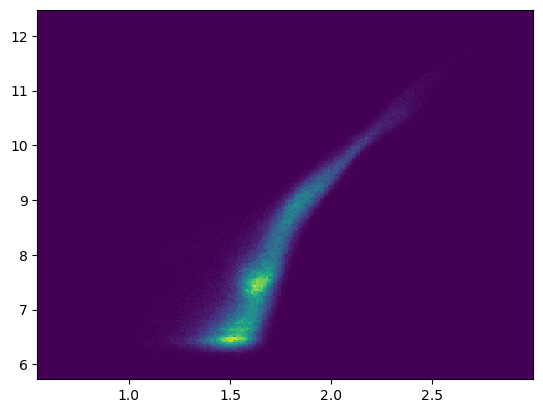

In [131]:
h,xs,ys,im  = plt.hist2d(np.log10(data['SubhaloVmax'][good_gals]),
                      Mstar_HI[good_gals], bins=(200,200))

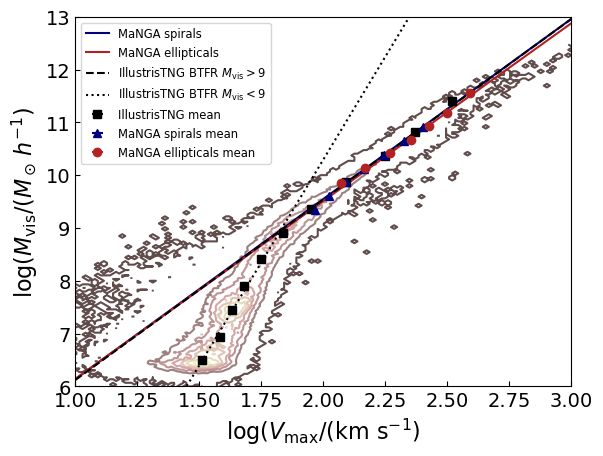

In [132]:
# plt.scatter(np.log10(data['SubhaloVmax'][good_gals]),
#                      Mstar_HI[good_gals], marker='.', s=1, color='tan', alpha=1, label='IllustrisTNG')

plt.contour(h.transpose(), extent=[xs.min(), xs.max(), ys.min(), ys.max()], cmap='pink', alpha=0.7
            )
plt.errorbar( mvis_veff_avg,veff_ctr, xerr=mvis_veff_sig, marker='s', color='k', linestyle='none', label='IllustrisTNG mean')

vs =np.linspace(1,3,100)

# plt.errorbar(is_mvis_veff_avg, is_veff_ctr, xerr=is_mvis_veff_sig, linestyle='none',
#             marker='s', color='blueviolet')
# plt.errorbar(ie_mvis_veff_avg, ie_veff_ctr, xerr=ie_mvis_veff_sig, linestyle='none',
#             marker='s', color='sienna')
plt.errorbar(s_mvis_veff_avg, s_veff_ctr, xerr=s_mvis_veff_sig, linestyle='none',
            marker='^', color='navy', label='MaNGA spirals mean')
plt.errorbar(e_mvis_veff_avg, e_veff_ctr, xerr=e_mvis_veff_sig, linestyle='none',
            marker='o', color='firebrick', label='MaNGA ellipticals mean')


plt.plot(vs, vs*s_slope + s_yint, color='navy', linestyle='-', label='MaNGA spirals')
plt.plot(vs, vs*e_slope + e_yint, color='firebrick', linestyle='-', label='MaNGA ellipticals')



# plt.plot(vs, vs/e_mvis_veff_popt[0] -e_mvis_veff_popt[1]/e_mvis_veff_popt[0], color='k', linestyle=':', label='IllustrisTNG BTFR')
plt.plot(vs, vs/e_mvis_veff_popt_2[0] -e_mvis_veff_popt_2[1]/e_mvis_veff_popt_2[0], color='k', linestyle='--', 
         label=r'IllustrisTNG BTFR $M_{\rm vis} > 9$')
plt.plot(vs, vs/e_mvis_veff_popt_3[0] -e_mvis_veff_popt_3[1]/e_mvis_veff_popt_3[0], color='k', linestyle=':', 
         label=r'IllustrisTNG BTFR $M_{\rm vis} < 9$')
plt.xlim(1,3)
plt.ylim(6,13)

plt.tick_params( axis='both', direction='in', labelsize=14)

plt.legend(fontsize='small')
plt.xlabel(r'$\log(V_{\rm max}/ (\rm km\,\, s^{-1})$', fontsize=16)
plt.ylabel(r'$\log(M_{\rm vis} / (M_\odot \, h^{-1})$', fontsize=16)

plt.savefig(plot_dir + 'BTFR/IllustrisTNG_BTFR_HI.png', bbox_inches='tight')

In [133]:
# write data to a file 
f = open(plot_dir + '/BTFR/all_tng/data.txt', 'x')
f.write('veff_centers \n')
f.write(str(veff_ctr) + '\n')
f.write('mvis_avgs \n')
f.write(str(mvis_veff_avg)+ '\n')
f.write('mvis_sigs \n')
f.write(str(mvis_veff_sig)+ '\n')

f.write('Mvis > 9 slope \n')
f.write(str(tng2_slope) + ' +- ' + str(tng2_err) + '\n')
f.write('y-int \n')
f.write(str(tng2_yint) + ' +- ' + str(tng2_yint_err)+ '\n')
f.write('chi2 nu \n')
f.write(str(chi2_2) + '\n')

f.write('Mvis < 9 slope \n')
f.write(str(tng3_slope) + ' +- ' + str(tng3_err) + '\n')
f.write('y-int \n')
f.write(str(tng3_yint) + ' +- ' + str(tng3_yint_err)+ '\n')
f.write('chi2 nu \n')
f.write(str(chi2_3) + '\n')


f.close()



## BPT

In [134]:
BPT_dict = {1.0: 'slateblue',
            2.0: 'limegreen',
            3.0:'lightcoral',
            0: 'k',}

BPT_m_dict = {1.0: 's',
              2.0: '^',
              3.0: 'o',
             0: '.'}
BPT_s_dict = {1.0: 5,
              2.0: 10,
              3.0: 10,
             0: 1}

def dust_corr(Ha, Hb, N2, O3, corr_law='CCM89'):
    
    rc= pn.RedCorr(law=corr_law)

    H_ratio = Ha/Hb

    rc.setCorr(H_ratio / 2.86, 6562, 4861)

    # in order Ha, Hb, NII, OIII
    wavelengths = np.array([6562, 4861, 6583, 5006])
    corr = rc.getCorrHb(wavelengths)

    Ha_corr = Ha * corr[0]
    Hb_corr = Hb * corr[1]
    N2_corr = N2 * corr[2]
    O3_corr = O3 * corr[3]

    return Ha_corr, Hb_corr, N2_corr, O3_corr

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_31108/4163645990.py:19: RuntimeWarning: divide by zero encountered in scalar divide
  H_ratio = Ha/Hb
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_31108/1296209287.py:10: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.log10(N2/Ha),
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_31108/1296209287.py:11: RuntimeWarning: divide by zero encountered in log10
  np.log10(O3/Hb),
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_31108/4163645990.py:19: RuntimeWarning: invalid value encountered in scalar divide
  H_ratio = Ha/Hb


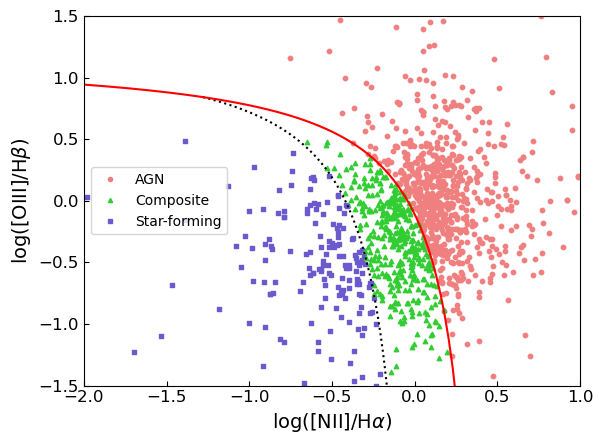

In [161]:
for i in range(len(ellipticals)):
    
    nsaid = ellipticals[i]['nsa_nsaid']
    nsa_idx = nsa_dict[nsaid]


    Ha, Hb, N2, O3 = dust_corr(nsa_portsmouth['Flux_Ha_6562'][nsa_idx], nsa_portsmouth['Flux_Hb_4861'][nsa_idx],
                               nsa_portsmouth['Flux_NII_6583'][nsa_idx], nsa_portsmouth['Flux_OIII_5006'][nsa_idx])

    plt.scatter(np.log10(N2/Ha),
                    np.log10(O3/Hb),
                    marker=BPT_m_dict[ellipticals[i]['BPT_class']], color=BPT_dict[ellipticals[i]['BPT_class']],
                    alpha=1, s=BPT_s_dict[ellipticals[i]['BPT_class']]
               )

plt.xlim(-2,1)
plt.ylim(-1.5,1.5)

x = np.linspace(-1.28,0,100)
plt.plot(x,0.61/(x-0.05) + 1.3, color='k', linestyle=':')
x1 = np.linspace(-2,0.4,100)
plt.plot(x1,0.61/(x1 - 0.47) + 1.19, color='r')

plt.xlabel(r'log([NII]/H$\alpha$)', fontsize=14)
plt.ylabel(r'log([OIII]/H$\beta$)', fontsize=14)


legend_elements = [Line2D([0], [0], marker='o', color='w', label='AGN',
                          markeredgecolor='lightcoral', mfc='lightcoral',markersize=3),
                   Line2D([0], [0], marker='^', color='w', label='Composite',
                          markeredgecolor='limegreen', mfc='limegreen',markersize=3),
                   Line2D([0], [0], marker='s', color='w', label='Star-forming',
                          markeredgecolor='slateblue', mfc='slateblue',markersize=3)]
plt.tick_params( axis='both', direction='in', labelsize=12)

plt.legend(handles=legend_elements)
plt.savefig(plot_dir + 'BPT/ellipticals_BPT.png', bbox_inches='tight')

In [136]:
u_ellipticals = ellipticals[ellipticals['BPT_class']==0]
sf_ellipticals = ellipticals[ellipticals['BPT_class']==1]
c_ellipticals = ellipticals[ellipticals['BPT_class']==2]
agn_ellipticals = ellipticals[ellipticals['BPT_class']==3]

In [137]:
bins = np.array([np.min(ellipticals['sphd_M_star_h'])-0.01,9.95,10.6,11.25,np.max(ellipticals['sphd_M_star_h'])])
ellipticals_mtot_mstar = 10**(ellipticals['Mvir'] - (ellipticals['sphd_M_star_h']))
agn_ellipticals_mtot_mstar = 10**(agn_ellipticals['Mvir'] - (agn_ellipticals['sphd_M_star_h']))
c_ellipticals_mtot_mstar = 10**(c_ellipticals['Mvir'] - (c_ellipticals['sphd_M_star_h']))
sf_ellipticals_mtot_mstar = 10**(sf_ellipticals['Mvir'] - (sf_ellipticals['sphd_M_star_h']))

#### all ellipticals

In [138]:
all_mtot = []
all_mtot_mstar = []
all_ctr = []

all_bins = bins

indices = np.digitize(ellipticals['sphd_M_star_h'], bins, right=True)

for i in range(1, len(bins)):
    all_mtot.append(ellipticals['Mvir'][indices==i])
    all_ctr.append(np.mean(ellipticals['sphd_M_star_h'][indices==i]))
    all_mtot_mstar.append(ellipticals_mtot_mstar[indices==i])


all_mtot_mstar_avg, all_mtot_mstar_sig = fit_to_gaussian(all_mtot_mstar, plot_dir = plot_dir + '/BPT/all/', 
                                                         plot_name='ellipticals_Mtot_Mstar', xlab=r'$M_{\rm tot} / M_*$',
                                                        use_custom_bins=True,
                                                        custom_bins=[np.concatenate((np.linspace(0,4,10), np.array([101,103]))),
                                                                     np.concatenate((np.linspace(0,6,20), np.array([80,82]))),
                                                                     33,
                                                                     33],
                                                        bin_lab = r'$M_*$', plot_bins=all_bins)
all_mtot_avg, all_mtot_sig = fit_to_gaussian(all_mtot, plot_dir = plot_dir+ '/BPT/all/', 
                                                         plot_name='all_ellipticals_Mtot', xlab=r'$M_{\rm tot}$',
                                             bin_lab = r'$M_*$', plot_bins=all_bins)

In [139]:
# write data to a file 
f = open(plot_dir + '/BPT/all/data.txt', 'x')
f.write('mstar_centers \n')
f.write(str(all_ctr) + '\n')
f.write('mtot_mstar_avgs \n')
f.write(str(all_mtot_mstar_avg)+ '\n')
f.write('mtot_mstar_sigs \n')
f.write(str(all_mtot_mstar_sig)+ '\n')

f.write('mtot_avgs \n')
f.write(str(all_mtot_avg)+ '\n')
f.write('mtot_sigs \n')
f.write(str(all_mtot_sig)+ '\n')

f.close()



#### sf

In [140]:
sf_mtot = []
sf_mtot_mstar = []
sf_ctr = []
sf_bins=bins
sf_bins = np.concatenate((bins[:1], bins[2:]))

indices = np.digitize(sf_ellipticals['sphd_M_star_h'], sf_bins, right=True)

for i in range(1, len(sf_bins)):
    sf_mtot.append(sf_ellipticals['Mvir'][indices==i])
    sf_ctr.append(np.mean(sf_ellipticals['sphd_M_star_h'][indices==i]))
    sf_mtot_mstar.append(sf_ellipticals_mtot_mstar[indices==i])


sf_mtot_mstar_avg, sf_mtot_mstar_sig = fit_to_gaussian(sf_mtot_mstar, plot_dir = plot_dir + '/BPT/sf/', 
                                                         plot_name='sf_ellipticals_Mtot_Mstar', xlab=r'$M_{\rm tot} / M_*$',
                                                       use_custom_bins=True,
                                                       custom_bins=[np.concatenate((np.linspace(0,5,7), np.array([80,82]))),
                                                                    8,
                                                                    8],
                                                      bin_lab = r'$M_*$', plot_bins=sf_bins)
sf_mtot_avg, sf_mtot_sig = fit_to_gaussian(sf_mtot, plot_dir = plot_dir + '/BPT/sf/', 
                                                         plot_name='sf__ellipticals_Mtot', xlab=r'$M_{\rm tot}$',
                                           bin_lab = r'$M_*$', plot_bins=sf_bins)

In [141]:
# write data to a file 
f = open(plot_dir + '/BPT/sf/data.txt', 'x')
f.write('mstar_centers \n')
f.write(str(sf_ctr) + '\n')
f.write('mtot_mstar_avgs \n')
f.write(str(sf_mtot_mstar_avg)+ '\n')
f.write('mtot_mstar_sigs \n')
f.write(str(sf_mtot_mstar_sig)+ '\n')

f.write('mtot_avgs \n')
f.write(str(sf_mtot_avg)+ '\n')
f.write('mtot_sigs \n')
f.write(str(sf_mtot_sig)+ '\n')

f.close()



In [142]:
c_mtot = []
c_mtot_mstar = []
c_ctr = []
c_bins=bins
# c_bins = np.concatenate((bins[:1], bins[2:]))

indices = np.digitize(c_ellipticals['sphd_M_star_h'], c_bins, right=True)

for i in range(1, len(c_bins)):
    c_mtot.append(c_ellipticals['Mvir'][indices==i])
    c_ctr.append(np.mean(c_ellipticals['sphd_M_star_h'][indices==i]))
    c_mtot_mstar.append(c_ellipticals_mtot_mstar[indices==i])


c_mtot_mstar_avg, c_mtot_mstar_sig = fit_to_gaussian(c_mtot_mstar, plot_dir = plot_dir + '/BPT/c/', 
                                                         plot_name='c_ellipticals_Mtot_Mstar', xlab=r'$M_{\rm tot} / M_*$',
                                                     bin_lab = r'$M_*$', plot_bins=c_bins)
c_mtot_avg, c_mtot_sig = fit_to_gaussian(c_mtot, plot_dir = plot_dir + '/BPT/c/', 
                                                         plot_name='c__ellipticals_Mtot', xlab=r'$M_{\rm tot}$',
                                         bin_lab = r'$M_*$', plot_bins=c_bins)

In [143]:
# write data to a file 
f = open(plot_dir + '/BPT/c/data.txt', 'x')
f.write('mstar_centers \n')
f.write(str(c_ctr) + '\n')
f.write('mtot_mstar_avgs \n')
f.write(str(c_mtot_mstar_avg)+ '\n')
f.write('mtot_mstar_sigs \n')
f.write(str(c_mtot_mstar_sig)+ '\n')

f.write('mtot_avgs \n')
f.write(str(c_mtot_avg)+ '\n')
f.write('mtot_sigs \n')
f.write(str(c_mtot_sig)+ '\n')

f.close()



#### agn

In [144]:
agn_mtot = []
agn_mtot_mstar = []
agn_ctr = []
agn_bins=bins
agn_bins = np.concatenate((bins[:1], bins[2:]))

indices = np.digitize(agn_ellipticals['sphd_M_star_h'], agn_bins, right=True)

for i in range(1, len(agn_bins)):
    agn_mtot.append(agn_ellipticals['Mvir'][indices==i])
    agn_ctr.append(np.mean(agn_ellipticals['sphd_M_star_h'][indices==i]))
    agn_mtot_mstar.append(agn_ellipticals_mtot_mstar[indices==i])


agn_mtot_mstar_avg, agn_mtot_mstar_sig = fit_to_gaussian(agn_mtot_mstar, plot_dir = plot_dir + '/BPT/agn/', 
                                                         plot_name='agn_ellipticals_Mtot_Mstar', xlab=r'$M_{\rm tot} / M_*$',
                                                         bin_lab = r'$M_*$', plot_bins=agn_bins)
agn_mtot_avg, agn_mtot_sig = fit_to_gaussian(agn_mtot, plot_dir = plot_dir + '/BPT/agn/', 
                                                         plot_name='agn_ellipticals_Mtot', xlab=r'$M_{\rm tot}$',
                                            bin_lab = r'$M_*$', plot_bins=agn_bins)

In [145]:
# write data to a file 
f = open(plot_dir + '/BPT/agn/data.txt', 'x')
f.write('mstar_centers \n')
f.write(str(agn_ctr) + '\n')
f.write('mtot_mstar_avgs \n')
f.write(str(agn_mtot_mstar_avg)+ '\n')
f.write('mtot_mstar_sigs \n')
f.write(str(agn_mtot_mstar_sig)+ '\n')

f.write('mtot_avgs \n')
f.write(str(agn_mtot_avg)+ '\n')
f.write('mtot_sigs \n')
f.write(str(agn_mtot_sig)+ '\n')

f.close()



### plot

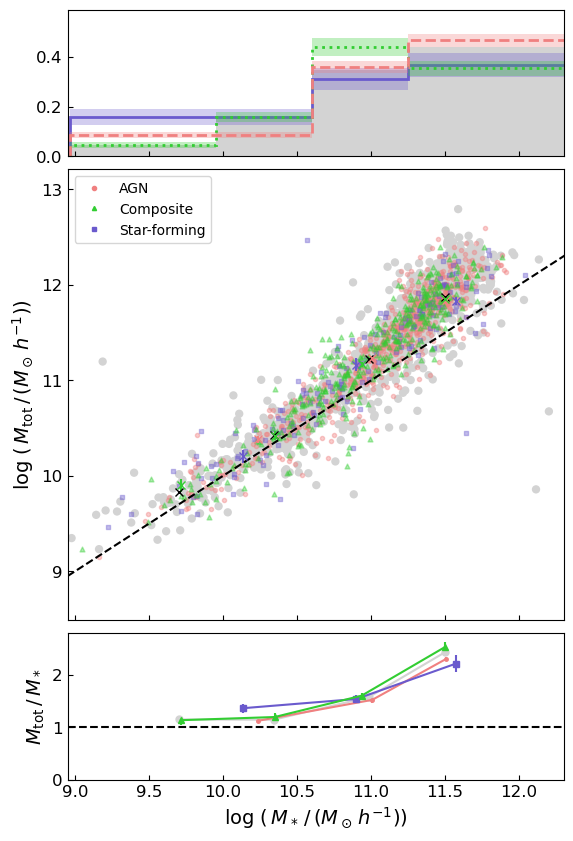

In [146]:
fig, ax = plt.subplots(3,1,sharex=True, height_ratios=(1.3,4, 1.3), figsize=(6.4,10))
ax[0].stairs([len(all_mtot[0])/len(ellipticals),len(all_mtot[1])/len(ellipticals),
              len(all_mtot[2])/len(ellipticals), len(all_mtot[3])/len(ellipticals)], all_bins, 
             color='lightgrey', fill=True, alpha=1, label=r'all ellipticals')

         
ax[0].stairs([len(sf_mtot[0])/ 2 / len(sf_ellipticals),len(sf_mtot[1])/len(sf_ellipticals),
              len(sf_mtot[2])/len(sf_ellipticals)], sf_bins,
             color='slateblue', alpha=1, lw=2)

ax[0].stairs([(len(sf_mtot[0])/2+np.sqrt(len(sf_mtot[0])/2))/len(sf_ellipticals),
              (len(sf_mtot[1])+np.sqrt(len(sf_mtot[1])))/len(sf_ellipticals),
              (len(sf_mtot[2])+np.sqrt(len(sf_mtot[2])))/len(sf_ellipticals)], 
                sf_bins,
                baseline=[(len(sf_mtot[0])/2-np.sqrt(len(sf_mtot[0])/2))/len(sf_ellipticals),
              (len(sf_mtot[1])-np.sqrt(len(sf_mtot[1])))/len(sf_ellipticals),
              (len(sf_mtot[2])-np.sqrt(len(sf_mtot[2])))/len(sf_ellipticals)],
             color='slateblue', alpha=0.3, lw=2, fill=True)

ax[0].stairs([len(c_mtot[0])/len(c_ellipticals),
              len(c_mtot[1])/len(c_ellipticals),
              len(c_mtot[2])/len(c_ellipticals),
              len(c_mtot[3])/len(c_ellipticals)], 
              c_bins,
             color='limegreen', alpha=1, linestyle=':',lw=2)

ax[0].stairs([(len(c_mtot[0])+np.sqrt(len(c_mtot[0])))/len(c_ellipticals),
              (len(c_mtot[1])+np.sqrt(len(c_mtot[1])))/len(c_ellipticals),
              (len(c_mtot[2])+np.sqrt(len(c_mtot[2])))/len(c_ellipticals),
              (len(c_mtot[3])+np.sqrt(len(c_mtot[3])))/len(c_ellipticals)],
             c_bins,
             baseline=[
                 (len(c_mtot[0])-np.sqrt(len(c_mtot[0])))/len(c_ellipticals),
                 (len(c_mtot[1])-np.sqrt(len(c_mtot[1])))/len(c_ellipticals),
                 (len(c_mtot[2])-np.sqrt(len(c_mtot[2])))/len(c_ellipticals),
                 (len(c_mtot[3])-np.sqrt(len(c_mtot[3])))/len(c_ellipticals)],
             color='limegreen', alpha=0.3, label=r'sf', lw=2, fill=True)


ax[0].stairs([len(agn_mtot[0])/2 / len(agn_ellipticals),
              len(agn_mtot[1])/len(agn_ellipticals),
              len(agn_mtot[2])/len(agn_ellipticals)],
             agn_bins,
             color='lightcoral', alpha=1, linestyle='--', lw=2)


ax[0].stairs([(len(agn_mtot[0])/2+np.sqrt(len(agn_mtot[0])/2))/len(agn_ellipticals),
              (len(agn_mtot[1])+np.sqrt(len(agn_mtot[1])))/len(agn_ellipticals),
              (len(agn_mtot[2])+np.sqrt(len(agn_mtot[2])))/len(agn_ellipticals)], 
             agn_bins,
                baseline=[(len(agn_mtot[0])/2-np.sqrt(len(agn_mtot[0])/2))/len(agn_ellipticals),
              (len(agn_mtot[1])-np.sqrt(len(agn_mtot[1])))/len(agn_ellipticals),
              (len(agn_mtot[2])-np.sqrt(len(agn_mtot[2])))/len(agn_ellipticals)],
             color='lightcoral', alpha=0.3, lw=2, fill=True)




ax[1].scatter(u_ellipticals['sphd_M_star_h'], u_ellipticals['Mvir'], color='lightgrey',edgecolor='none', alpha=1)
ax[1].scatter(agn_ellipticals['sphd_M_star_h'], agn_ellipticals['Mvir'], color='lightcoral', marker='.', alpha=0.4)
ax[1].scatter(sf_ellipticals['sphd_M_star_h'], sf_ellipticals['Mvir'], color='slateblue', marker='s', alpha=0.4, s=8)
ax[1].scatter(c_ellipticals['sphd_M_star_h'], c_ellipticals['Mvir'], color='limegreen', marker='^', alpha=0.4, s=12)


ax[1].errorbar(all_ctr, all_mtot_avg, yerr=all_mtot_sig, marker='x', color='k', linestyle='none')
ax[1].errorbar(agn_ctr, agn_mtot_avg, yerr=agn_mtot_sig, marker='x', color='lightcoral', linestyle='none')
ax[1].errorbar(sf_ctr, sf_mtot_avg, yerr=sf_mtot_sig, marker='x', color='slateblue', linestyle='none')
ax[1].errorbar(c_ctr, c_mtot_avg, yerr=c_mtot_sig, marker='x', color='limegreen', linestyle='none')

ax[1].set_xlim(8.95,12.3)
ax[2].set_xlabel(r'$\log\,(\,M_*\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
ax[1].set_ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)

legend_elements = [Line2D([0], [0], marker='o', color='w', label='AGN',
                          markeredgecolor='lightcoral', mfc='lightcoral',markersize=3),
                   Line2D([0], [0], marker='^', color='w', label='Composite',
                          markeredgecolor='limegreen', mfc='limegreen',markersize=3),
                   Line2D([0], [0], marker='s', color='w', label='Star-forming',
                          markeredgecolor='slateblue', mfc='slateblue', markersize=3)]

ax[1].tick_params( axis='both', direction='in', labelsize=12)
ax[0].tick_params( axis='both', direction='in', labelsize=12)
ax[2].tick_params( axis='both', direction='in', labelsize=12)
ax[1].plot([8.7,13],[8.7,13], color='k', linestyle='--')
ax[0].set_ylim(0,0.59)



ax[2].errorbar(all_ctr, all_mtot_mstar_avg, color='lightgrey', yerr=np.abs(all_mtot_mstar_sig), 
             marker='o', markersize=5, )

ax[2].errorbar(agn_ctr, agn_mtot_mstar_avg, color='lightcoral', yerr=np.abs(agn_mtot_mstar_sig), 
             marker='.', markersize=5, )
ax[2].errorbar(sf_ctr, sf_mtot_mstar_avg, color='slateblue', yerr=np.abs(sf_mtot_mstar_sig), 
             marker='s', markersize=5, )
ax[2].errorbar(c_ctr, c_mtot_mstar_avg, color='limegreen', yerr=np.abs(c_mtot_mstar_sig), 
             marker='^', markersize=5, )


ax[2].axhline(1 , color='k', linestyle='--')

ax[2].set_ylim(0,2.8)
ax[2].set_ylabel(r'$M_{\rm tot}\, /\, M_*$', fontsize=14)


fig.subplots_adjust(hspace=0.05)
ax[1].legend(handles=legend_elements)
plt.savefig(plot_dir + 'BPT/Mtot_Mstar_BPT_hist.png', bbox_inches='tight')

## metallicity

In [147]:
counts, Zbins = np.histogram(ellipticals['ZH_LW_Re_fit'][ellipticals['ZH_LW_Re_fit']>-99])
bin_ctrs = (Zbins[:-1] + Zbins[1:])/2
popt, pcov = curve_fit(gaussian, bin_ctrs, counts)
popt

array([ 6.91815843e+02, -3.43295267e-02,  9.64313276e-02])

In [148]:
z_bins = np.array([np.min(ellipticals['ZH_LW_Re_fit'][ellipticals['ZH_LW_Re_fit']>-99]-0.01),
                   popt[1]-popt[2], popt[1]+popt[2],
                     np.max(ellipticals['ZH_LW_Re_fit'][ellipticals['ZH_LW_Re_fit']>-99])])
good_z_ellipticals = ellipticals[ellipticals['ZH_LW_Re_fit']>-99]

z_indices = np.digitize(good_z_ellipticals['ZH_LW_Re_fit'], z_bins)

low_z = good_z_ellipticals[z_indices==1]
mid_z = good_z_ellipticals[z_indices==2]
high_z = good_z_ellipticals[z_indices==3]

low_z_ellipticals_mtot_mstar = 10**(low_z['Mvir'] - (low_z['sphd_M_star_h']))
mid_z_ellipticals_mtot_mstar = 10**(mid_z['Mvir'] - (mid_z['sphd_M_star_h']))
high_z_ellipticals_mtot_mstar = 10**(high_z['Mvir'] - (high_z['sphd_M_star_h']))



#### low z

In [149]:
low_z_mtot_mstar = []
low_z_mtot = []
low_z_ctr = []

low_z_bins = bins
# low_z_bins = np.concatenate((bins[:1], bins[2:]))

indices = np.digitize(low_z['sphd_M_star_h'], low_z_bins)

for i in range(1, len(low_z_bins)):

    low_z_mtot.append(low_z['Mvir'][indices==i])
    low_z_mtot_mstar.append(low_z_ellipticals_mtot_mstar[indices==i])
    low_z_ctr.append(np.mean(low_z['sphd_M_star_h'][indices==i]))
    

low_z_mtot_mstar_avg, low_z_mtot_mstar_sig = fit_to_gaussian(low_z_mtot_mstar, plot_dir = plot_dir + '/metallicity/lowz/', 
                                                         plot_name='low_z_Mtot_Mstar', xlab=r'$M_{\rm tot}/M_*$',
                                                            use_custom_bins=True,
                                                             custom_bins=[np.concatenate((np.linspace(0,4,10), np.array([101,103]))),
                                                                     np.concatenate((np.linspace(0,6,20), np.array([80,82]))),
                                                                     13,
                                                                     13],
                                                             plot_bins=low_z_bins, bin_lab=r'$M_*$'
                                                            )


low_z_mtot_avg, low_z_mtot_sig = fit_to_gaussian(low_z_mtot, plot_dir = plot_dir + '/metallicity/lowz/', 
                                                         plot_name='low_z_Mtot', xlab=r'$M_{\rm tot}$',
                                                plot_bins=low_z_bins, bin_lab=r'$M_*$')


low_z_mtot_popt, low_z_mtot_pcov = curve_fit(lin_fit, low_z_ctr, 
                                       low_z_mtot_avg, sigma=low_z_mtot_sig)

# print(low_z_mtot_popt, np.sqrt(low_z_mtot_pcov[0,0]), np.sqrt(low_z_mtot_pcov[1,1]))

low_z_slope = low_z_mtot_popt[0]
low_z_slope_err = np.sqrt(low_z_mtot_pcov[0,0])

low_z_yint = low_z_mtot_popt[1]
low_z_yint_err = np.sqrt(low_z_mtot_pcov[1,1])


In [150]:
f = open(plot_dir + '/metallicity/lowz/data.txt', 'x')
f.write('zbin edge \n')
f.write(str(z_bins[0]) + ' ' + str(z_bins[1]))
f.write('mstar_centers \n')
f.write(str(low_z_ctr) + '\n')
f.write('mtot_mstar_avgs \n')
f.write(str(low_z_mtot_mstar_avg)+ '\n')
f.write('mtot_mstar_sigs \n')
f.write(str(low_z_mtot_mstar_sig)+ '\n')

f.write('mtot_avgs \n')
f.write(str(low_z_mtot_avg)+ '\n')
f.write('mtot_sigs \n')
f.write(str(low_z_mtot_sig)+ '\n')

f.write('mtot_slope \n')
f.write(str(low_z_slope)+ ' +- ' + str(low_z_slope_err) + '\n')
f.write('mtot_yint \n')
f.write(str(low_z_yint)+ ' +- ' + str(low_z_yint_err) + '\n')

f.close()


#### mid z

In [151]:
mid_z_mtot_mstar = []
mid_z_mtot = []
mid_z_ctr = []

mid_z_bins = bins
mid_z_bins = np.concatenate((bins[:1], bins[2:]))

indices = np.digitize(mid_z['sphd_M_star_h'], mid_z_bins)

for i in range(1, len(mid_z_bins)):

    mid_z_mtot.append(mid_z['Mvir'][indices==i])
    mid_z_mtot_mstar.append(mid_z_ellipticals_mtot_mstar[indices==i])
    mid_z_ctr.append(np.mean(mid_z['sphd_M_star_h'][indices==i]))
    

mid_z_mtot_mstar_avg, mid_z_mtot_mstar_sig = fit_to_gaussian(mid_z_mtot_mstar, plot_dir = plot_dir + '/metallicity/midz/', 
                                                         plot_name='mid_z_Mtot_Mstar', xlab=r'$M_{\rm tot}/M_*$',
                                                            plot_bins=mid_z_bins, bin_lab=r'$M_*$')


mid_z_mtot_avg, mid_z_mtot_sig = fit_to_gaussian(mid_z_mtot, plot_dir = plot_dir + '/metallicity/midz/', 
                                                         plot_name='mid_z_Mtot', xlab=r'$M_{\rm tot}$',
                                                plot_bins= mid_z_bins, bin_lab=r'$M_*$')

mid_z_mtot_popt, mid_z_mtot_pcov = curve_fit(lin_fit, mid_z_ctr, 
                                       mid_z_mtot_avg, sigma=mid_z_mtot_sig)


mid_z_slope = mid_z_mtot_popt[0]
mid_z_slope_err = np.sqrt(mid_z_mtot_pcov[0,0])

mid_z_yint = mid_z_mtot_popt[1]
mid_z_yint_err = np.sqrt(mid_z_mtot_pcov[1,1])

In [152]:
f = open(plot_dir + '/metallicity/midz/data.txt', 'x')
f.write('zbin edge \n')
f.write(str(z_bins[1]) + ' ' + str(z_bins[2]))
f.write('mstar_centers \n')
f.write(str(mid_z_ctr) + '\n')
f.write('mtot_mstar_avgs \n')
f.write(str(mid_z_mtot_mstar_avg)+ '\n')
f.write('mtot_mstar_sigs \n')
f.write(str(mid_z_mtot_mstar_sig)+ '\n')

f.write('mtot_avgs \n')
f.write(str(mid_z_mtot_avg)+ '\n')
f.write('mtot_sigs \n')
f.write(str(mid_z_mtot_sig)+ '\n')

f.write('mtot_slope \n')
f.write(str(mid_z_slope)+ ' +- ' + str(mid_z_slope_err) + '\n')
f.write('mtot_yint \n')
f.write(str(mid_z_yint)+ ' +- ' + str(mid_z_yint_err) + '\n')

f.close()


#### high z

In [153]:
high_z_mtot_mstar = []
high_z_mtot = []
high_z_ctr = []

high_z_bins = bins
high_z_bins = np.concatenate((bins[:1], bins[2:]))

indices = np.digitize(high_z['sphd_M_star_h'], high_z_bins)

for i in range(1, len(high_z_bins)):

    high_z_mtot.append(high_z['Mvir'][indices==i])
    high_z_mtot_mstar.append(high_z_ellipticals_mtot_mstar[indices==i])
    high_z_ctr.append(np.mean(high_z['sphd_M_star_h'][indices==i]))
    

high_z_mtot_mstar_avg, high_z_mtot_mstar_sig = fit_to_gaussian(high_z_mtot_mstar, plot_dir = plot_dir + '/metallicity/highz/', 
                                                         plot_name='high_z_Mtot_Mstar', xlab=r'$M_{\rm tot}/M_*$',
                                                              use_custom_bins=True,
                                                              custom_bins=[np.linspace(0,2,5),
                                                                           9,
                                                                           13
                                                              ],
                                                               plot_bins=high_z_bins, bin_lab=r'$M_*$')
                                                              


high_z_mtot_avg, high_z_mtot_sig = fit_to_gaussian(high_z_mtot, plot_dir =  plot_dir + '/metallicity/highz/', 
                                                         plot_name='high_z_Mtot', xlab=r'$M_{\rm tot}$',
                                                  plot_bins=high_z_bins, bin_lab=r'$M_*$')

high_z_mtot_popt, high_z_mtot_pcov = curve_fit(lin_fit, high_z_ctr, 
                                       high_z_mtot_avg, sigma=high_z_mtot_sig)

# print(high_z_mtot_popt, np.sqrt(hgih_z_mtot_pcov[0,0]), np.sqrt(hgih_z_mtot_pcov[1,1]))

high_z_slope = high_z_mtot_popt[0]
high_z_slope_err = np.sqrt(high_z_mtot_pcov[0,0])

high_z_yint = high_z_mtot_popt[1]
high_z_yint_err = np.sqrt(high_z_mtot_pcov[1,1])

In [154]:
f = open(plot_dir + '/metallicity/highz/data.txt', 'x')
f.write('zbin edge \n')
f.write(str(z_bins[2]) + ' ' + str(z_bins[3]))
f.write('mstar_centers \n')
f.write(str(high_z_ctr) + '\n')
f.write('mtot_mstar_avgs \n')
f.write(str(high_z_mtot_mstar_avg)+ '\n')
f.write('mtot_mstar_sigs \n')
f.write(str(high_z_mtot_mstar_sig)+ '\n')

f.write('mtot_avgs \n')
f.write(str(high_z_mtot_avg)+ '\n')
f.write('mtot_sigs \n')
f.write(str(high_z_mtot_sig)+ '\n')

f.write('mtot_slope \n')
f.write(str(high_z_slope)+ ' +- ' + str(high_z_slope_err) + '\n')
f.write('mtot_yint \n')
f.write(str(high_z_yint)+ ' +- ' + str(high_z_yint_err) + '\n')

f.close()


### plot

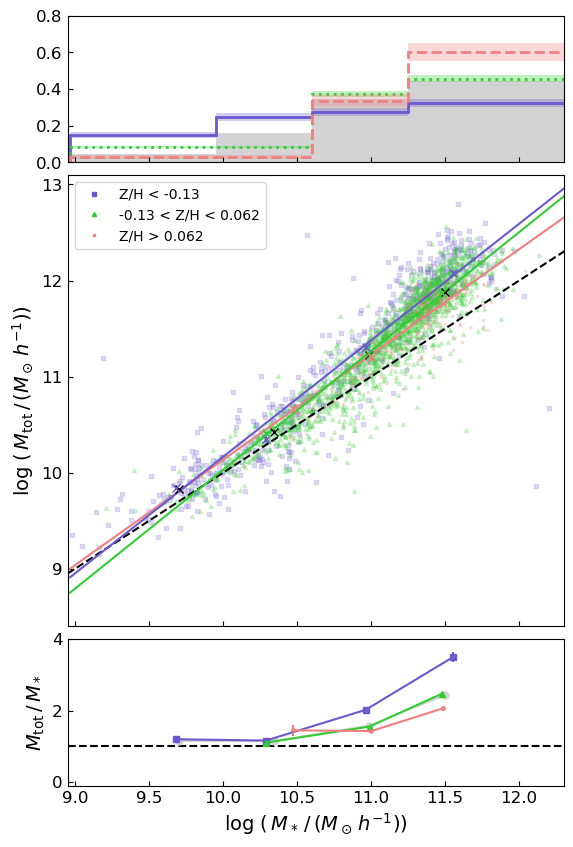

In [155]:
fig, ax = plt.subplots(3,1,sharex=True, height_ratios=(1.3,4, 1.3), figsize=(6.4,10))
ax[0].stairs([len(all_mtot[0])/len(ellipticals),len(all_mtot[1])/len(ellipticals),
              len(all_mtot[2])/len(ellipticals), len(all_mtot[3])/len(ellipticals)], all_bins, 
             color='lightgrey', fill=True, alpha=1, label=r'all ellipticals')

         
ax[0].stairs([len(low_z_mtot[0])/len(low_z),len(low_z_mtot[1])/len(low_z),
              len(low_z_mtot[2])/len(low_z), len(low_z_mtot[3])/len(low_z)], 
             low_z_bins,
             color='slateblue', alpha=1, label=r'low Z', lw=2)

ax[0].stairs([(len(low_z_mtot[0])+np.sqrt(len(low_z_mtot[0])))/len(low_z),
              (len(low_z_mtot[1])+np.sqrt(len(low_z_mtot[1])))/len(low_z),
              (len(low_z_mtot[2])+np.sqrt(len(low_z_mtot[2])))/len(low_z), 
              (len(low_z_mtot[3])+np.sqrt(len(low_z_mtot[3])))/len(low_z)], 
             low_z_bins,
                baseline=[(len(low_z_mtot[0])-np.sqrt(len(low_z_mtot[0])))/len(low_z),
              (len(low_z_mtot[1])-np.sqrt(len(low_z_mtot[1])))/len(low_z),
              (len(low_z_mtot[2])-np.sqrt(len(low_z_mtot[2])))/len(low_z), 
              (len(low_z_mtot[3])-np.sqrt(len(low_z_mtot[3])))/len(low_z)],
             color='slateblue', alpha=0.3, label=r'sf', lw=2, fill=True)

ax[0].stairs([len(mid_z_mtot[0])/2 / len(mid_z),
              len(mid_z_mtot[1])/len(mid_z),
              len(mid_z_mtot[2])/len(mid_z)], mid_z_bins,
             color='limegreen', alpha=1, label=r'mid Z', linestyle=':',lw=2)

ax[0].stairs([(len(mid_z_mtot[0])/2 +np.sqrt(len(mid_z_mtot[0])/2))/ len(mid_z),
              (len(mid_z_mtot[1])+np.sqrt(len(mid_z_mtot[1])))/len(mid_z),
              (len(mid_z_mtot[2])+np.sqrt(len(mid_z_mtot[2])))/len(mid_z)],
             mid_z_bins,
                baseline=[(len(mid_z_mtot[0])/2 -np.sqrt(len(mid_z_mtot[0])/2))/ len(mid_z),
              (len(mid_z_mtot[1])-np.sqrt(len(mid_z_mtot[1])))/len(mid_z),
              (len(mid_z_mtot[2])-np.sqrt(len(mid_z_mtot[2])))/len(mid_z)],
             color='limegreen', alpha=0.3, lw=2, fill=True)



ax[0].stairs([len(high_z_mtot[0])/2 /len(high_z),
              len(high_z_mtot[1])/len(high_z),
              len(high_z_mtot[2])/len(high_z)], 
             high_z_bins,
             color='lightcoral', alpha=1, label=r'high Z', linestyle='--', lw=2)


ax[0].stairs([(len(high_z_mtot[0])/2 + np.sqrt(len(high_z_mtot[0])/2))/len(high_z),
              (len(high_z_mtot[1]) + np.sqrt(len(high_z_mtot[1])))/len(high_z),
              (len(high_z_mtot[2]) + np.sqrt(len(high_z_mtot[2])))/len(high_z)], 
             high_z_bins,
                baseline=[(len(high_z_mtot[0])/2 - np.sqrt(len(high_z_mtot[0])/2))/len(high_z),
              (len(high_z_mtot[1]) - np.sqrt(len(high_z_mtot[1])))/len(high_z),
              (len(high_z_mtot[2]) - np.sqrt(len(high_z_mtot[2])))/len(high_z)],
             color='lightcoral', alpha=0.3, label=r'sf', lw=2, fill=True)




# ax[1].scatter(ellipticals['sphd_M_star_h'], ellipticals['Mvir'], color='lightgrey',edgecolor='none', alpha=1)
ax[1].scatter(low_z['sphd_M_star_h'], low_z['Mvir'], color='slateblue', marker='s', alpha=0.2, s=8)
ax[1].scatter(mid_z['sphd_M_star_h'], mid_z['Mvir'], color='limegreen', marker='^', alpha=0.2, s=8)
ax[1].scatter(high_z['sphd_M_star_h'], high_z['Mvir'], color='lightcoral', marker='.', alpha=0.2, s=12)


ax[1].errorbar(all_ctr, all_mtot_avg, yerr=all_mtot_sig, marker='x', color='k', linestyle='none')
ax[1].errorbar(low_z_ctr, low_z_mtot_avg, yerr=low_z_mtot_sig, marker='x', color='slateblue', linestyle='none')
ax[1].errorbar(mid_z_ctr, mid_z_mtot_avg, yerr=mid_z_mtot_sig, marker='x', color='limegreen', linestyle='none')
ax[1].errorbar(high_z_ctr, high_z_mtot_avg, yerr=high_z_mtot_sig, marker='x', color='lightcoral', linestyle='none')

ax[1].set_xlim(8.95,12.3)
ax[2].set_xlabel(r'$\log\,(\,M_*\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
ax[1].set_ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)

legend_elements = [Line2D([0], [0], marker='s', color='w', label=f'Z/H < {z_bins[1]:.2}',
                          markeredgecolor='slateblue', mfc='slateblue',markersize=3),
                   Line2D([0], [0], marker='^', color='w', label=f'{z_bins[1]:.2} < Z/H < {z_bins[2]:.2}',
                          markeredgecolor='limegreen', mfc='limegreen',markersize=3),
                   Line2D([0], [0], marker='.', color='w', label=f'Z/H > {z_bins[2]:.2}',
                          markeredgecolor='lightcoral', mfc='lightcoral', markersize=3)]

ax[1].tick_params( axis='both', direction='in', labelsize=12)
ax[0].tick_params( axis='both', direction='in', labelsize=12)
ax[2].tick_params( axis='both', direction='in', labelsize=12)
ax[1].plot([8.7,13],[8.7,13], color='k', linestyle='--')
ax[0].set_ylim(0,0.8)



ax[2].errorbar(all_ctr, all_mtot_mstar_avg, color='lightgrey', yerr=np.abs(all_mtot_mstar_sig), 
             marker='o', markersize=5, )

ax[2].errorbar(low_z_ctr, low_z_mtot_mstar_avg, color='slateblue', yerr=np.abs(low_z_mtot_mstar_sig), 
             marker='s', markersize=5, )
ax[2].errorbar(mid_z_ctr, mid_z_mtot_mstar_avg, color='limegreen', yerr=np.abs(mid_z_mtot_mstar_sig), 
             marker='^', markersize=5, )
ax[2].errorbar(high_z_ctr, high_z_mtot_mstar_avg, color='lightcoral', yerr=np.abs(high_z_mtot_mstar_sig), 
             marker='.', markersize=5, )

ax[1].plot(bins,  high_z_mtot_popt[0]*bins + high_z_mtot_popt[1], color='lightcoral')
ax[1].plot(bins,  mid_z_mtot_popt[0]*bins + mid_z_mtot_popt[1], color='limegreen')
ax[1].plot(bins,  low_z_mtot_popt[0]*bins + low_z_mtot_popt[1], color='slateblue')



ax[2].axhline(1 , color='k', linestyle='--')

ax[1].set_ylim(8.4,13.1)
ax[2].set_ylim(-0.1,4)
ax[2].set_ylabel(r'$M_{\rm tot}\, /\, M_*$', fontsize=14)


fig.subplots_adjust(hspace=0.05)
ax[1].legend(handles=legend_elements)
plt.savefig(plot_dir + 'metallicity/Mtot_Mstar_ZH_hist.png', bbox_inches='tight')

## stellar evolution

In [156]:
bins = np.linspace(9.3,11.9,5)
bin1 = ellipticals[ellipticals['sphd_M_star']+np.log10(0.73) < bins[1]]
bin2 = ellipticals[np.logical_and(ellipticals['sphd_M_star']+np.log10(0.73) > bins[1], ellipticals['sphd_M_star']+np.log10(0.73) < bins[2])]
bin3 = ellipticals[np.logical_and(ellipticals['sphd_M_star']+np.log10(0.73) > bins[2], ellipticals['sphd_M_star']+np.log10(0.73) < bins[3])]
bin4 = ellipticals[ellipticals['sphd_M_star']+np.log10(0.73) > bins[3]]

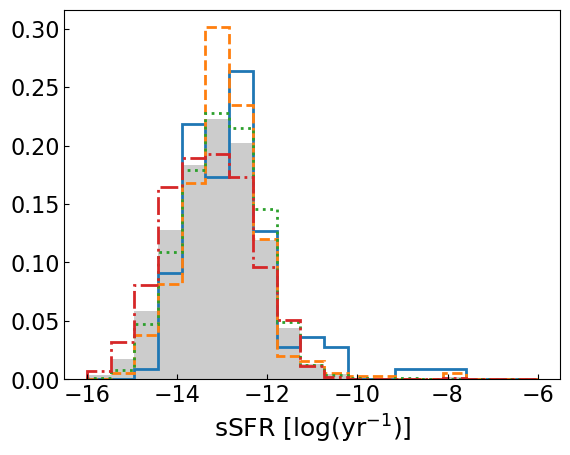

In [157]:
sfr_bins = np.linspace(-16,-6,20)

counts, bins = np.histogram(ellipticals['SFR'] - ellipticals['sphd_M_star']-np.log10(0.73), bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='k', fill=True, alpha=0.2, label=r'all ellipticals')


counts, bins = np.histogram(bin1['SFR']- bin1['sphd_M_star']-np.log10(0.73), bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:blue', label=r'$\log(M_{*,model}/M_\odot)$ < 10.125', lw=2)

counts, bins = np.histogram(bin2['SFR'] - bin2['sphd_M_star']-np.log10(0.73), bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:orange', label=r'10.125 < $\log(M_{*,model}/M_\odot)$ < 10.75', linestyle='--', lw=2)

counts, bins = np.histogram(bin3['SFR'] - bin3['sphd_M_star']-np.log10(0.73), bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:green', label=r'10.75 < $\log(M_{*,model}/M_\odot)$ < 11.375', linestyle=':', lw=2)

counts, bins = np.histogram(bin4['SFR'] - bin4['sphd_M_star']-np.log10(0.73), bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:red', label=r'$\log(M_{*,model}/M_\odot)$ > 11.375', linestyle='-.',lw=2)


# plt.legend()

plt.xlabel(r'sSFR [$\log(\rm yr^{-1})$]', fontsize=18)
plt.tick_params(axis='both', direction='in', labelsize=16)

plt.savefig(plot_dir + '/stellar_age/' + 'Mtot_Mstar_bin_sSFR_hist_stacked.png', bbox_inches='tight')

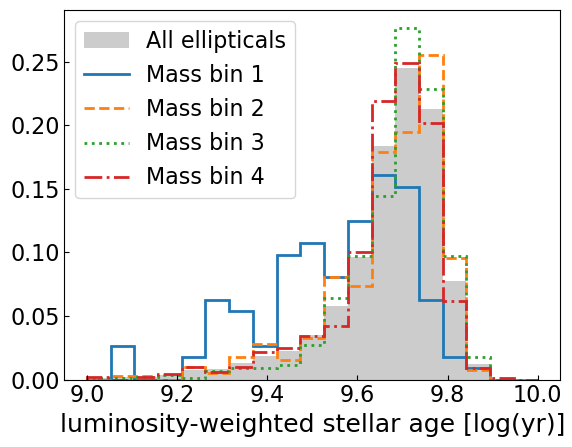

In [158]:
age_bins = np.linspace(9,10,20)

counts, bins = np.histogram(ellipticals['Age_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='k', fill=True, alpha=0.2, label=r'All ellipticals')


counts, bins = np.histogram(bin1['Age_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:blue', label=r'Mass bin 1', lw=2)

counts, bins = np.histogram(bin2['Age_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:orange', label=r'Mass bin 2', linestyle='--', lw=2)

counts, bins = np.histogram(bin3['Age_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:green', label=r'Mass bin 3', linestyle=':', lw=2)

counts, bins = np.histogram(bin4['Age_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:red', label=r'Mass bin 4', linestyle='-.', lw=2)


plt.xlabel(r'luminosity-weighted stellar age [log(yr)]', fontsize=18)
plt.legend(fontsize=16)
plt.tick_params(axis='both', direction='in', labelsize=16)

plt.savefig(plot_dir + '/stellar_age/' + 'Mtot_Mstar_bin_LW_age_hist_stacked.png', bbox_inches='tight')

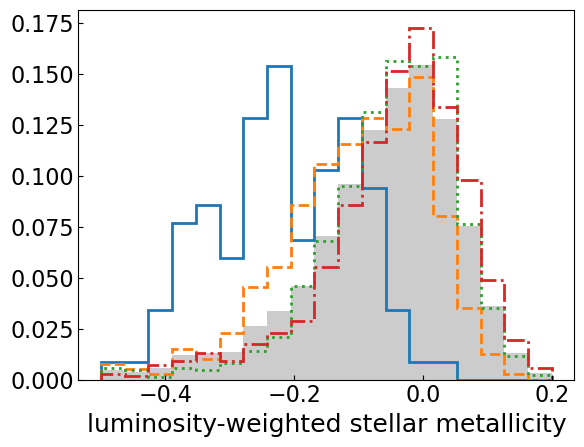

In [159]:
age_bins = np.linspace(-0.5,0.2,20)

counts, bins = np.histogram(ellipticals['ZH_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='k', fill=True, alpha=0.2, label=r'all ellipticals')


counts, bins = np.histogram(bin1['ZH_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:blue', label=r'$\log(M_{*,model}/M_\odot)$ < 10.125', lw=2)

counts, bins = np.histogram(bin2['ZH_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:orange', label=r'10.125 < $\log(M_{*,model}/M_\odot)$ < 10.75', linestyle='--', lw=2)

counts, bins = np.histogram(bin3['ZH_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:green', label=r'10.75 < $\log(M_{*,model}/M_\odot)$ < 11.375', linestyle=':', lw=2)

counts, bins = np.histogram(bin4['ZH_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:red', label=r'$\log(M_{*,model}/M_\odot)$ > 11.375', linestyle='-.', lw=2)


plt.xlabel(r'luminosity-weighted stellar metallicity', fontsize=18)
# plt.legend()
plt.tick_params(axis='both', direction='in', labelsize=16)

plt.savefig(plot_dir + '/stellar_age/' +  'Mtot_Mstar_bin_LW_Z_hist_stacked.png', bbox_inches='tight')